# Digitdeck · Entregable M1 — Fine-tuning de encoder para ranking de relevancia

**Tópicos Especiales y Aplicaciones en IA** · Universidad EAFIT · SI4006 · Semestre 2026-2

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

---

**Equipo:** Maximiliano Bustamante · Valeria Frances Hornung · Sebastián Castaño · Alejandro Posada

**Repositorio:** [AlejandroSPosada/Topicos_IA_Proyecto_Digitdeck](https://github.com/AlejandroSPosada/Topicos_IA_Proyecto_Digitdeck)

---

Este notebook documenta el trabajo del equipo para el Módulo 1 del curso: selección y
justificación del modelo base, construcción del dataset ESCI en español, fine-tuning de un
**encoder** (`intfloat/multilingual-e5-small`) con una cabeza de clasificación binaria, y
evaluación comparativa contra los baselines definidos en el `README.md` del proyecto
(BM25 y E5-small congelado), con nDCG@10 como métrica primaria.


## 0 · Entorno de trabajo

In [ ]:
# Instalación del ecosistema Hugging Face + BM25 + Weights & Biases. ~1-2 min la primera vez.
# Si Colab pide RESTART RUNTIME, reinicia y vuelve a ejecutar desde esta celda.
%pip install -q transformers datasets accelerate evaluate sentence-transformers rank_bm25 wandb 
print("Librerías instaladas.")

Note: you may need to restart the kernel to use updated packages.
Librerías instaladas.


ERROR: Could not find a version that satisfies the requirement cuda (from versions: none)
ERROR: No matching distribution found for cuda


In [4]:
# Registro del entorno de entrenamiento para garantizar reproducibilidad (criterio 3).
import importlib.metadata as meta
import sys, torch, random, numpy as np

SEMILLA = 42  # semilla global del proyecto — se reutiliza en todas las secciones

def fijar_semilla(seed: int = SEMILLA):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

fijar_semilla(SEMILLA)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("=== Entorno de entrenamiento ===")
print(f"Python      : {sys.version.split()[0]}")
print(f"Dispositivo : {DEVICE}", end="")
print(f" | {torch.cuda.get_device_name(0)}" if DEVICE == "cuda" else " [AVISO: sin GPU activa — secciones 3 y 4 serán lentas]")
print(f"Semilla     : {SEMILLA}")
print()
for pkg in ["torch", "transformers", "datasets", "accelerate", "evaluate", "sentence_transformers", "rank_bm25", "wandb"]:
    try:
        print(f"  {pkg:<22} {meta.version(pkg)}")
    except meta.PackageNotFoundError:
        print(f"  {pkg:<22} FALTA")

=== Entorno de entrenamiento ===
Python      : 3.11.9
Dispositivo : cuda | NVIDIA GeForce RTX 5060 Ti
Semilla     : 42

  torch                  2.11.0+cu128
  transformers           4.57.1
  datasets               5.0.1
  accelerate             1.14.0
  evaluate               0.4.6
  sentence_transformers  5.1.2
  rank_bm25              0.2.2
  wandb                  0.28.2


**Pendiente manual (TODO §0, no scriptable):**
- Abrir [`S04_Lab_Fine_tuning_SOLUCION.ipynb`](../../Clases/M1/S04_Lab_Fine_tuning_SOLUCION.ipynb)
  en Colab y verificar que corre de punta a punta con GPU T4 antes de continuar.
- Crear cuenta en [Hugging Face](https://huggingface.co) y generar un token de acceso si el
  equipo va a subir el modelo entrenado al Hub (§3.10, opcional).


In [5]:
# Login opcional a Hugging Face Hub — solo necesario si se va a ejecutar la celda
# opcional de §3.10 (subir el modelo fine-tuned al Hub). Se puede saltar sin problema.
SUBIR_A_HUB = False  # cambiar a True y ejecutar login() si el equipo decide subir el modelo

if SUBIR_A_HUB:
    from huggingface_hub import login
    login()
else:
    print("SUBIR_A_HUB = False — celda de login omitida.")

SUBIR_A_HUB = False — celda de login omitida.


## 0.1 · Weights & Biases (observabilidad del entrenamiento)

W&B no es opcional en este proyecto: la entrega pide observabilidad verificable y la curva de
pérdida es la evidencia mínima. El `Trainer` de Hugging Face la registra solo si se le pasa
`report_to="wandb"` en `TrainingArguments` (§3.5), que es lo que configura esta celda.

Al ejecutarla, W&B pide la API key: se obtiene en https://wandb.ai/authorize con una cuenta
gratuita. Si el login falla, `USAR_WANDB` queda en `False` y el notebook sigue corriendo sin
W&B, pero la entrega quedaría incompleta en ese punto.

In [6]:
import os

USAR_WANDB     = True                  # requisito de M1: la entrega pide observabilidad verificable
WANDB_PROYECTO = "digitdeck-m1"
WANDB_RUN_NAME = "e5-small-esci-es-ft"

os.environ["WANDB_PROJECT"]   = WANDB_PROYECTO
os.environ["WANDB_LOG_MODEL"] = "false"   # solo métricas y curvas; los pesos van al Hub (§3.11)

if USAR_WANDB:
    try:
        import wandb
        wandb.login()                      # pide la API key de https://wandb.ai/authorize
        print(f"W&B activo | proyecto: {WANDB_PROYECTO} | corrida: {WANDB_RUN_NAME}")
    except Exception as e:
        USAR_WANDB = False
        print(f"AVISO: no se pudo activar W&B ({type(e).__name__}: {e}).")
        print("El notebook sigue corriendo, pero la entrega quedaría sin el requisito de observabilidad.")

REPORTE_ENTRENAMIENTO = "wandb" if USAR_WANDB else "none"
print(f"report_to = {REPORTE_ENTRENAMIENTO!r}")

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: WARNING Invalid choice
wandb: Enter your choice:wandb: WARNING Invalid choice
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\sebas\_netrc
wandb: Currently logged in as: scastanoa1 (scastano) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B activo | proyecto: digitdeck-m1 | corrida: e5-small-esci-es-ft
report_to = 'wandb'


---

# 1 · Selección y justificación del modelo base

## 1.1 · Variantes a evaluar

Siguiendo la decisión técnica documentada en el `README.md`, el equipo no compara modelos
causales entre sí: compara **estrategias de scoring de relevancia** bajo el mismo split ESCI
y el mismo presupuesto de GPU T4. El candidato eficiente es `intfloat/multilingual-e5-small`,
un encoder multilingüe (~117 M parámetros), evaluado contra un techo léxico (BM25) y contra
su propia versión sin fine-tuning (congelada) — esto último para aislar el efecto del
fine-tuning del efecto del pre-entrenamiento.

| Variante | Entrenamiento | Métrica primaria | Guardrails |
|---|---|---|---|
| BM25 | Ninguno | nDCG@10 | latencia, tamaño de índice |
| E5-small congelado | Ninguno | nDCG@10 | memoria, p95 |
| **E5-small ajustado** ← candidato | Pares/grados ESCI es | nDCG@10 | MRR, Recall@10, memoria, p95 |
| E5-base ajustado *(opcional)* | Mismo split; mayor presupuesto | nDCG@10 | mejora por costo |

**Por qué esta lista y no otra:**
- **BM25** es el techo léxico clásico de recuperación — sin él, la tabla de resultados no
  tiene punto de referencia no neuronal.
- **E5-small congelado** separa el efecto del encoder pre-entrenado del efecto del
  fine-tuning: si ya supera a BM25 sin haber visto un solo ejemplo de ESCI, el argumento de
  invertir en fine-tuning se fortalece; si no lo supera, es un hallazgo honesto que también
  se reporta.
- **E5-small ajustado** es el candidato real de M1: multilingüe, visto en clase (S01),
  ~117 M parámetros — dentro del presupuesto T4 con margen amplio para batch size y `fp16`.
- **E5-base ajustado** es una ablación de tamaño (opcional, ~278 M parámetros): permite leer
  si el costo adicional de cómputo se traduce en mejora de nDCG@10.
- **BGE-M3 + reranker** queda descartado de M1: su arquitectura de dos etapas (retriever +
  cross-encoder) no permite comparación bajo las mismas condiciones que las demás variantes,
  y su p95 en T4 es prohibitiva para el caso de uso. Candidato natural para M2/M3.

## 1.2 · Atributos registrados desde las model cards oficiales

In [7]:
# Atributos de cada variante encoder, tomados de las model cards oficiales en Hugging Face.
# BM25 no tiene "model card": es un algoritmo léxico, no una red neuronal — se documenta aparte.
VARIANTES_ENCODER = [
    {
        "id":        "intfloat/multilingual-e5-small",
        "rol":       "Candidato M1 (congelado y ajustado)",
        "params_m":  118,
        "disco_mb":  470,
        "familia":   "E5 (XLM-RoBERTa base multilingüe)",
        "idiomas":   "100 idiomas (incl. español)",
        "licencia":  "MIT",
        "hf_url":    "https://huggingface.co/intfloat/multilingual-e5-small",
    },
    {
        "id":        "intfloat/multilingual-e5-base",
        "rol":       "Ablación opcional (§3.10)",
        "params_m":  278,
        "disco_mb":  1110,
        "familia":   "E5 (XLM-RoBERTa base multilingüe)",
        "idiomas":   "100 idiomas (incl. español)",
        "licencia":  "MIT",
        "hf_url":    "https://huggingface.co/intfloat/multilingual-e5-base",
    },
]

import pandas as pd
pd.set_option("display.max_colwidth", None)

df_variantes = pd.DataFrame(VARIANTES_ENCODER).rename(columns={
    "id": "Modelo", "rol": "Rol en M1", "params_m": "Params (M)",
    "disco_mb": "Disco (MB)", "familia": "Familia", "idiomas": "Cobertura idiomas",
    "licencia": "Licencia", "hf_url": "Model card",
})
df_variantes

,Modelo,Rol en M1,Params (M),Disco (MB),Familia,Cobertura idiomas,Licencia,Model card
0,intfloat/multilingual-e5-small,Candidato M1 (congelado y ajustado),118,470,E5 (XLM-RoBERTa base multilingüe),100 idiomas (incl. español),MIT,https://huggingface.co/intfloat/multilingual-e5-small
1,intfloat/multilingual-e5-base,Ablación opcional (§3.10),278,1110,E5 (XLM-RoBERTa base multilingüe),100 idiomas (incl. español),MIT,https://huggingface.co/intfloat/multilingual-e5-base


**BM25 — la variante no neuronal de la tabla:**

| Atributo | Detalle |
|---|---|
| Implementación | `rank_bm25.BM25Okapi` (Python, CPU) |
| Parámetros aprendidos | Ninguno — es un modelo estadístico (frecuencia de términos + IDF) |
| Licencia | MIT (paquete `rank_bm25`) |
| Guardrail relevante | Tamaño de índice y latencia de scoring, no memoria de GPU |

## 1.3 · Muestra de consultas del dominio

15–20 consultas representativas del dominio de ecommerce en español: nombres de producto,
marcas, tildes, abreviaturas, spanglish y errores de tecleo comunes — el tipo de texto real
que Digitdeck tiene que rankear.

In [8]:
# Muestra de 18 consultas representativas del dominio (cubre tildes, marcas,
# abreviaturas, spanglish y errores comunes de tecleo).
MUESTRA_DOMINIO = [
    "televisión 4K 55 pulgadas",                                        # tilde
    "auriculares inalámbricos cancelación de ruido",                    # tilde + compuesto largo
    "Samsung Galaxy S24 Ultra",                                         # marca + modelo
    "Xiaomi Redmi Note 13",                                             # marca + modelo
    "PlayStation 5 edición digital",                                    # marca + tilde
    "ASUS TUF Gaming F15 FX506",                                        # marca + código de modelo
    "HDMI 2.1 cable 2m",                                                # abreviatura técnica
    "smartwatch deportivo waterproof",                                  # spanglish + anglicismo
    "laptop gamer RTX 4060",                                            # spanglish + sigla
    "celular libre 5G doble SIM",                                       # abreviatura + sigla
    "impresora multifuncional wifi tinta",                              # anglicismo
    "audifono bluetooth sony",                                          # sin tilde (error común: "audífono")
    "tableta grafica wacom",                                            # sin tilde (error común: "gráfica")
    "procesador Intel Core i7 13ava generación socket 1700",            # técnico largo
    "silla ergonómica gamer con soporte lumbar y reposapiés ajustable", # tilde + compuesto largo
    "cel xiaomi redmi 13 128gb",                                        # abreviatura "cel" + minúsculas
    "auricular bluetoth sony wh1000xm5",                                # error de tecleo ("bluetoth")
    "mochila p/ portatil 15.6 pulg impermeable",                        # abreviaturas "p/" y "pulg"
]

print(f"{len(MUESTRA_DOMINIO)} consultas preparadas (tildes, marcas, abreviaturas, spanglish, errores comunes).")

18 consultas preparadas (tildes, marcas, abreviaturas, spanglish, errores comunes).


## 1.4 · Análisis de tokenizador sobre texto del dominio

Se comparan los tokenizadores de las dos variantes E5 y, como contraste, dos de **otras
familias**: BETO (monolingüe español) y DistilBERT multilingüe. Sin ese contraste el análisis
no diría nada, porque E5-small y E5-base comparten tokenizador y fragmentan idéntico.

Menos tokens para el mismo texto significa menos posiciones gastadas en partir palabras del
dominio (marcas, tildes, abreviaturas) y más señal por posición dentro del límite de 64 tokens
que usa el fine-tuning.

In [ ]:
from transformers import AutoTokenizer

# Tokenizadores de las dos variantes E5 (candidato y ablación).
print("Cargando tokenizadores de las variantes E5...")
tokenizadores = {}
for v in VARIANTES_ENCODER:
    tokenizadores[v["id"]] = AutoTokenizer.from_pretrained(v["id"])
    print(f"  OK  {v['id']:<45} vocab: {tokenizadores[v['id']].vocab_size:>9,}")

TOKENIZADORES_CONTRASTE = {
    "dccuchile/bert-base-spanish-wwm-uncased": "BETO — monolingüe español (WordPiece)",
    "distilbert-base-multilingual-cased":      "DistilBERT multilingüe (WordPiece 119k)",
}
for tid, desc in TOKENIZADORES_CONTRASTE.items():
    try:
        tokenizadores[tid] = AutoTokenizer.from_pretrained(tid)
        print(f"  OK  {tid:<45} vocab: {tokenizadores[tid].vocab_size:>9,}  [{desc}]")
    except Exception as e:
        print(f"  FALLO {tid}: {type(e).__name__} — se omite del contraste (no bloquea el notebook).")

print(f"\n{len(tokenizadores)} tokenizadores cargados "
      f"({len(VARIANTES_ENCODER)} variantes E5 + {len(tokenizadores) - len(VARIANTES_ENCODER)} de contraste).")

C:\Users\sebas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cargando tokenizadores de las variantes E5...


C:\Users\sebas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sebas\.cache\huggingface\hub\models--intfloat--multilingual-e5-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is en

  OK  intfloat/multilingual-e5-small                vocab:   250,002


C:\Users\sebas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sebas\.cache\huggingface\hub\models--intfloat--multilingual-e5-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is ena

  OK  intfloat/multilingual-e5-base                 vocab:   250,002


C:\Users\sebas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sebas\.cache\huggingface\hub\models--dccuchile--bert-base-spanish-wwm-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


  OK  dccuchile/bert-base-spanish-wwm-uncased       vocab:    31,002  [BETO — monolingüe español (WordPiece)]


C:\Users\sebas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sebas\.cache\huggingface\hub\models--distilbert-base-multilingual-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


  OK  distilbert-base-multilingual-cased            vocab:   119,547  [DistilBERT multilingüe (WordPiece 119k)]

4 tokenizadores cargados (2 variantes E5 + 2 de contraste).


In [10]:
def comparar(texto, nombre_corto=True):
    '''Muestra cómo cada tokenizador fragmenta el mismo texto.'''
    filas = []
    for model_id, tok in tokenizadores.items():
        nombre = model_id.split("/")[-1] if nombre_corto else model_id
        piezas = tok.tokenize(texto)
        filas.append({
            "Modelo":   nombre,
            "N tokens": len(piezas),
            "Tokens":   " | ".join(piezas),
        })
    return pd.DataFrame(filas).set_index("Modelo")

# Casos mostrados: los 4 primeros (tildes y marcas) y los 4 últimos (spanglish, errores de
# tecleo y abreviaturas) — que son donde una mala segmentación duele de verdad.
CASOS_MOSTRAR = MUESTRA_DOMINIO[:4] + MUESTRA_DOMINIO[-4:]
for texto in CASOS_MOSTRAR:
    print(f"\n--- '{texto}' ---")
    display(comparar(texto))


--- 'televisión 4K 55 pulgadas' ---


,N tokens,Tokens
Modelo,,
multilingual-e5-small,7,▁televisión | ▁4 | K | ▁55 | ▁pul | gada | s
multilingual-e5-base,7,▁televisión | ▁4 | K | ▁55 | ▁pul | gada | s
bert-base-spanish-wwm-uncased,5,televisión | 4 | ##k | 55 | pulgadas
distilbert-base-multilingual-cased,7,televisión | 4 | ##K | 55 | pu | ##lga | ##das



--- 'auriculares inalámbricos cancelación de ruido' ---


,N tokens,Tokens
Modelo,,
multilingual-e5-small,12,▁a | uri | culare | s | ▁ina | lám | bric | os | ▁cancel | ación | ▁de | ▁ruido
multilingual-e5-base,12,▁a | uri | culare | s | ▁ina | lám | bric | os | ▁cancel | ación | ▁de | ▁ruido
bert-base-spanish-wwm-uncased,8,aur | ##iculares | inalám | ##brico | ##s | cancelación | de | ruido
distilbert-base-multilingual-cased,13,aur | ##icular | ##es | ina | ##lá | ##mb | ##ricos | can | ##cel | ##ación | de | ru | ##ido



--- 'Samsung Galaxy S24 Ultra' ---


...

,N tokens,Tokens
Modelo,,
multilingual-e5-small,9,▁cel | ▁ | xia | omi | ▁red | mi | ▁13 | ▁128 | gb
multilingual-e5-base,9,▁cel | ▁ | xia | omi | ▁red | mi | ▁13 | ▁128 | gb
bert-base-spanish-wwm-uncased,10,cel | xi | ##a | ##omi | red | ##mi | 13 | 12 | ##8 | ##gb
distilbert-base-multilingual-cased,10,cel | x | ##ia | ##omi | red | ##mi | 13 | 128 | ##g | ##b



--- 'auricular bluetoth sony wh1000xm5' ---


,N tokens,Tokens
Modelo,,
multilingual-e5-small,14,▁a | uri | cular | ▁blue | to | th | ▁son | y | ▁w | h | 1000 | x | m | 5
multilingual-e5-base,14,▁a | uri | cular | ▁blue | to | th | ▁son | y | ▁w | h | 1000 | x | m | 5
bert-base-spanish-wwm-uncased,13,aur | ##icular | blue | ##to | ##th | sony | w | ##h | ##100 | ##0 | ##x | ##m | ##5
distilbert-base-multilingual-cased,14,aur | ##icular | blue | ##tot | ##h | son | ##y | w | ##h | ##100 | ##0 | ##x | ##m | ##5



--- 'mochila p/ portatil 15.6 pulg impermeable' ---


,N tokens,Tokens
Modelo,,
multilingual-e5-small,12,▁mochila | ▁p | / | ▁porta | til | ▁15. | 6 | ▁pul | g | ▁imper | me | able
multilingual-e5-base,12,▁mochila | ▁p | / | ▁porta | til | ▁15. | 6 | ▁pul | g | ▁imper | me | able
bert-base-spanish-wwm-uncased,13,mochila | p | / | porta | ##til | 15 | . | 6 | pul | ##g | imper | ##mea | ##ble
distilbert-base-multilingual-cased,16,moc | ##hil | ##a | p | / | porta | ##til | 15 | . | 6 | pu | ##lg | im | ##per | ##mea | ##ble


In [ ]:

filas_total = []
for model_id, tok in tokenizadores.items():
    conteos  = [len(tok.tokenize(t)) for t in MUESTRA_DOMINIO]
    total    = sum(conteos)
    promedio = total / len(conteos)
    filas_total.append({
        "Modelo":         model_id.split("/")[-1],
        "Familia":        "E5 (candidato)" if model_id in [v["id"] for v in VARIANTES_ENCODER] else "contraste",
        "Total tokens":   total,
        "Promedio/frase": round(promedio, 1),
        "Vocab size":     f"{tok.vocab_size:,}",
    })

df_total = pd.DataFrame(filas_total).set_index("Modelo").sort_values("Total tokens")
print("Costo de tokenización sobre las 18 consultas del dominio (menor es mejor):")
print(df_total.to_string())
df_total.style.background_gradient(subset=["Total tokens", "Promedio/frase"], cmap="YlOrRd")

Costo de tokenización sobre las 18 consultas del dominio (menor es mejor):
                                           Familia  Total tokens  Promedio/frase Vocab size
Modelo                                                                                     
multilingual-e5-small               E5 (candidato)           147             8.2    250,002
multilingual-e5-base                E5 (candidato)           147             8.2    250,002
bert-base-spanish-wwm-uncased            contraste           164             9.1     31,002
distilbert-base-multilingual-cased       contraste           171             9.5    119,547


,Familia,Total tokens,Promedio/frase,Vocab size
Modelo,,,,
multilingual-e5-small,E5 (candidato),147,8.200000,"250,002"
multilingual-e5-base,E5 (candidato),147,8.200000,"250,002"
bert-base-spanish-wwm-uncased,contraste,164,9.100000,"31,002"
distilbert-base-multilingual-cased,contraste,171,9.500000,"119,547"


In [ ]:

TERMINOS_CRITICOS = [
    "televisión", "auriculares", "inalámbricos", "ergonómica", "reposapiés",
    "Samsung", "Xiaomi", "PlayStation", "RTX", "wacom",
    "smartwatch", "laptop", "bluetooth", "waterproof", "vitroceramica",
]

filas_criticos = []
for term in TERMINOS_CRITICOS:
    fila = {"Término": term}
    for model_id, tok in tokenizadores.items():
        fila[model_id.split("/")[-1]] = len(tok.tokenize(term))
    filas_criticos.append(fila)

df_criticos = pd.DataFrame(filas_criticos).set_index("Término")
print("Número de tokens por término — menor indica mejor cobertura del dominio:")
print(df_criticos.to_string())
print("\nPromedio de tokens por término crítico:")
print(df_criticos.mean().round(2).to_string())
df_criticos.style.background_gradient(cmap="YlOrRd", axis=1)

Número de tokens por término — menor indica mejor cobertura del dominio:
               multilingual-e5-small  multilingual-e5-base  bert-base-spanish-wwm-uncased  distilbert-base-multilingual-cased
Término                                                                                                                      
televisión                         1                     1                              1                                   1
auriculares                        4                     4                              2                                   3
inalámbricos                       4                     4                              3                                   4
ergonómica                         3                     3                              3                                   4
reposapiés                         3                     3                              4                                   4
Samsung                            1         

,multilingual-e5-small,multilingual-e5-base,bert-base-spanish-wwm-uncased,distilbert-base-multilingual-cased
Término,,,,
televisión,1,1,1,1
auriculares,4,4,2,3
inalámbricos,4,4,3,4
ergonómica,3,3,3,4
reposapiés,3,3,4,4
Samsung,1,1,3,1
Xiaomi,1,1,3,2
PlayStation,1,1,1,1
RTX,2,2,2,2


## 1.5 · Justificación del modelo elegido

> **Cómo leer §1.4:** E5-small y E5-base comparten el mismo tokenizador (SentencePiece de
> XLM-RoBERTa, 250.002 piezas), así que entre ellos la tokenización **no** es variable de
> decisión: la diferencia está en la capacidad del encoder (`hidden_size` 384 vs. 768) y en el
> costo de fine-tuning. Por eso §1.4 incluye además dos tokenizadores de **otras familias**
> (BETO monolingüe español y DistilBERT multilingüe): ahí sí hay contraste real, y es la
> evidencia que sostiene la elección de familia sobre texto de ecommerce en español.

### Pregunta que el argumento debe resistir: ¿por qué no usar E5-base directamente?

E5-base tiene más del doble de parámetros que E5-small (278 M vs. 118 M) y, en benchmarks
multilingües publicados por el autor, suele rendir mejor en tareas de recuperación. Pero para
M1 el equipo elige **E5-small** como candidato principal por tres razones concretas:

1. **Presupuesto T4 compartido entre las cuatro variantes.** El mismo notebook debe entrenar
   y evaluar BM25, E5-small congelado, E5-small ajustado y, opcionalmente, E5-base ajustado,
   todo en una sesión de Colab con GPU T4 (16 GB VRAM, límite de tiempo de sesión). E5-small
   deja margen para batch sizes más grandes e iteración rápida; E5-base es la ablación que se
   corre *si el tiempo lo permite*, no el punto de partida.
2. **La ganancia de E5-base es una pregunta empírica, no una suposición.** En vez de asumir
   que "más grande es mejor", el equipo lo deja como comparación explícita en la tabla de
   §4.6: si E5-base ajustado mejora nDCG@10 lo suficiente para justificar el costo adicional
   de cómputo, esa es la evidencia — no una preferencia a priori.
3. **E5-small ya fue introducido en clase (S01)** como el encoder multilingüe de referencia,
   lo que da continuidad pedagógica y una base de comparación con el material del curso.

### Decisión

El equipo adopta **`intfloat/multilingual-e5-small`** como candidato principal de M1, con
`intfloat/multilingual-e5-base` como ablación opcional de tamaño. La decisión de
si el fine-tuning realmente aporta sobre BM25 y sobre el encoder congelado **no se asume aquí**
— se responde con las métricas de la sección 4.

### Limitaciones conocidas de esta sección

- El contraste de tokenizadores mide **costo de segmentación**, no calidad de ranking: es
  evidencia necesaria pero no suficiente. La evidencia decisiva está en §4.
- La muestra de 18 consultas es representativa pero pequeña; no cubre todas las categorías
  del catálogo de Digitdeck.

---

# 2 · Dataset: construcción y documentación

## 2.0 · Descripción del dataset

Se usa el **Amazon Shopping Queries Dataset (ESCI)**, publicado por Amazon Science bajo
licencia Apache 2.0. Es el único dataset público de relevancia de búsqueda con anotaciones
en español a escala suficiente para fine-tuning.

| Atributo | Detalle |
|---|---|
| **Fuente** | [amazon-science/esci-data](https://github.com/amazon-science/esci-data) |
| **Licencia** | Apache 2.0 |
| **Idiomas** | Inglés, Español, Japonés |
| **Subconjunto ES** | ~8,049 queries · ~218,774 pares query-producto |
| **Etiquetas** | `E` Exact · `S` Substitute · `C` Complement · `I` Irrelevant |
| **Campos usados** | `query`, `product_title`, `product_locale`, `esci_label`, `split` |
| **Splits** | `train` y `test` predefinidos en el dataset |

**Mapeo de etiquetas ESCI a formato binario para el encoder de clasificación:**

| ESCI | Significado | Etiqueta modelo |
|---|---|---|
| `E` (Exact) | Producto que responde directamente la consulta | `relevante` (1) |
| `S` (Substitute) | Producto alternativo, posiblemente útil | `no relevante` (0) |
| `C` (Complement) | Producto complementario | `no relevante` (0) |
| `I` (Irrelevant) | Sin relación con la consulta | `no relevante` (0) |

Se usa el mapeo binario `E → relevante`, `S+C+I → no relevante` para simplificar la tarea
en M1. La pérdida de información en `S` y `C` se documenta como limitación conocida (§2.8).

## 2.1 · Descarga del dataset ESCI

Los archivos están en Git LFS. Se descargan directamente con `wget` usando la URL de medios
de GitHub. Tiempos aproximados en Colab T4:
- `examples.parquet` (~300 MB): ~1 min
- `products.parquet` (~1.7 GB): ~5-8 min

In [13]:
import os, urllib.request

BASE_URL = "https://github.com/amazon-science/esci-data/raw/main/shopping_queries_dataset"
ARCHIVOS = [
    "shopping_queries_dataset_examples.parquet",
    "shopping_queries_dataset_products.parquet",
]

for archivo in ARCHIVOS:
    if os.path.exists(archivo) and os.path.getsize(archivo) < 1e6:
        os.remove(archivo)   # puntero de Git LFS, no el archivo real

    if os.path.exists(archivo):
        print(f"  Ya existe: {archivo} ({os.path.getsize(archivo)/1e6:.1f} MB) — omitiendo descarga.")
    else:
        print(f"  Descargando {archivo} ...")
        urllib.request.urlretrieve(f"{BASE_URL}/{archivo}", archivo)
        print(f"  Descargado: {archivo} ({os.path.getsize(archivo)/1e6:.1f} MB)")

print("Descarga completada con éxito.")

  Descargando shopping_queries_dataset_examples.parquet ...
  Descargado: shopping_queries_dataset_examples.parquet (51.3 MB)
  Descargando shopping_queries_dataset_products.parquet ...
  Descargado: shopping_queries_dataset_products.parquet (1108.9 MB)
Descarga completada con éxito.


## 2.2 · Carga y filtrado del subconjunto español

In [14]:
import pandas as pd

# --- Cargar ejemplos (pares query-producto con etiqueta) ---
print("Cargando examples.parquet ...")
df_ex = pd.read_parquet(
    "shopping_queries_dataset_examples.parquet",
    columns=["query_id", "product_id", "query", "esci_label", "split", "product_locale"],
)
print(f"  Total pares (todos los idiomas): {len(df_ex):,}")

# Filtrar subconjunto español
df_es = df_ex[df_ex["product_locale"] == "es"].copy()
print(f"  Pares en español (es):           {len(df_es):,}")
print(f"  Queries únicas (es):             {df_es['query_id'].nunique():,}")
print(f"  Distribución de splits:")
print(df_es["split"].value_counts().to_string())
print(f"  Distribución de etiquetas ESCI:")
print(df_es["esci_label"].value_counts().to_string())

Cargando examples.parquet ...
  Total pares (todos los idiomas): 2,621,288
  Pares en español (es):           356,410
  Queries únicas (es):             15,180
  Distribución de splits:
split
train    263063
test      93347
  Distribución de etiquetas ESCI:
esci_label
E    202066
S     89059
I     44782
C     20503


In [15]:
# --- Cargar productos (títulos) ---
# Solo cargamos product_id y product_title para minimizar uso de memoria.
print("Cargando products.parquet (solo columnas necesarias) ...")
product_ids_es = set(df_es["product_id"].unique())

df_prod = pd.read_parquet(
    "shopping_queries_dataset_products.parquet",
    columns=["product_id", "product_title", "product_locale"],
    filters=[("product_locale", "==", "es")],
)
print(f"  Productos en español cargados: {len(df_prod):,}")

# Join: ejemplos + títulos de producto
df = df_es.merge(df_prod[["product_id", "product_title"]], on="product_id", how="left")
print(f"  Pares con título de producto:  {len(df):,}")
print(f"  Pares sin título (nulos):      {df['product_title'].isna().sum():,}")

Cargando products.parquet (solo columnas necesarias) ...
  Productos en español cargados: 260,011
  Pares con título de producto:  356,410
  Pares sin título (nulos):      0


## 2.3 · Criterios de inclusión/exclusión y limpieza reproducible

In [16]:
import re

def limpiar_texto(texto: str) -> str:
    '''Normalización reproducible: minúsculas, colapso de espacios.'''
    if not isinstance(texto, str):
        return ""
    texto = texto.lower()
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

def n_palabras(texto: str) -> int:
    '''Cuenta palabras en un texto ya limpio.'''
    return len(texto.split()) if isinstance(texto, str) else 0


n_antes = len(df)

# 1. Eliminar filas con product_title nulo
df = df.dropna(subset=["product_title"])
print(f"Tras eliminar titles nulos:         {len(df):,}  (-{n_antes - len(df):,})")

# 2. Normalizar texto
df["query"]         = df["query"].map(limpiar_texto)
df["product_title"] = df["product_title"].map(limpiar_texto)

# 3. Descartar product_title con menos de 3 palabras
n_antes = len(df)
df = df[df["product_title"].map(n_palabras) >= 3]
print(f"Tras filtrar titles cortos (<3 palabras): {len(df):,}  (-{n_antes - len(df):,})")

# 4. Deduplicar por (query_id, product_id)
n_antes = len(df)
df = df.drop_duplicates(subset=["query_id", "product_id"])
print(f"Tras deduplicar (query_id, product_id): {len(df):,}  (-{n_antes - len(df):,})")

print(f"\nDataset limpio final: {len(df):,} pares")
print(df["split"].value_counts().to_string())

Tras eliminar titles nulos:         356,410  (-0)
Tras filtrar titles cortos (<3 palabras): 354,288  (-2,122)
Tras deduplicar (query_id, product_id): 354,288  (-0)

Dataset limpio final: 354,288 pares
split
train    261549
test      92739


## 2.4 · Mapeo de etiquetas y formateo para clasificación con el encoder

In [17]:
# Mapeo ESCI → binario
MAPEO_ETIQUETA = {
    "E": 1,   # Exact match       -> relevante
    "S": 0,   # Substitute        -> no relevante
    "C": 0,   # Complement        -> no relevante
    "I": 0,   # Irrelevant        -> no relevante
}
MAPEO_NOMBRE = {1: "relevante", 0: "no relevante"}

df["label"] = df["esci_label"].map(MAPEO_ETIQUETA)

print("Distribución de etiquetas tras el mapeo binario:")
print(df["label"].map(MAPEO_NOMBRE).value_counts().to_string())
pct = df["label"].map(MAPEO_NOMBRE).value_counts(normalize=True).mul(100).round(1)
print(f"\nBalance: {pct.get('relevante', 0):.1f}% relevante / {pct.get('no relevante', 0):.1f}% no relevante")

Distribución de etiquetas tras el mapeo binario:
label
relevante       200936
no relevante    153352

Balance: 56.7% relevante / 43.3% no relevante


In [18]:
# Formato de par de texto + etiqueta numérica para el encoder de clasificación.
# E5 espera los prefijos "query: " y "passage: " en sus dos lados del par (ver model card
# de intfloat/multilingual-e5-small): el modelo fue pre-entrenado distinguiendo el rol de
# cada texto, y usar el mismo prefijo en fine-tuning mantiene esa señal.
def formatear_par(fila):
    return pd.Series({
        "text_a": f"query: {fila['query']}",
        "text_b": f"passage: {fila['product_title']}",
        "label":  int(fila["label"]),
    })

pares = df.apply(formatear_par, axis=1)
df["text_a"] = pares["text_a"]
df["text_b"] = pares["text_b"]

# Mostrar ejemplos representativos
ejemplo_rel   = df[df["label"] == 1].iloc[0]
ejemplo_norel = df[df["label"] == 0].iloc[0]

print("--- Ejemplo: RELEVANTE (label=1) ---")
print(f"  text_a: {ejemplo_rel['text_a']}")
print(f"  text_b: {ejemplo_rel['text_b']}")
print("\n--- Ejemplo: NO RELEVANTE (label=0) ---")
print(f"  text_a: {ejemplo_norel['text_a']}")
print(f"  text_b: {ejemplo_norel['text_b']}")
print(f"\n{{'text_a': query, 'text_b': product_title, 'label': 1|0}} — formato final por fila.")

--- Ejemplo: RELEVANTE (label=1) ---
  text_a: query: !solid camiseta sin manga
  text_b: passage: tuc tuc punto tropicool camiseta sin mangas para bebés y niños pequeños, blanco, 4a

--- Ejemplo: NO RELEVANTE (label=0) ---
  text_a: query: !solid camiseta sin manga
  text_b: passage: aloha hawaii piña con gafas de sol regalo de playa #3 camiseta sin mangas

{'text_a': query, 'text_b': product_title, 'label': 1|0} — formato final por fila.


## 2.5 · Splits: train / validación / test

El dataset ESCI trae splits `train` y `test` predefinidos, y se usan tal cual para que la
evaluación sea comparable con otros trabajos sobre el mismo dataset.

Del split de train se aparta además un split de **validación**, agrupando por `query_id`:

- El **modelo se selecciona** (mejor checkpoint y parada temprana) mirando **solo validación**.
- El split de **test** se reserva para el reporte final de la sección 4.

Agrupar por `query_id` es indispensable: si la misma consulta quedara repartida entre train y
validación, el modelo vería en entrenamiento otros productos de la misma consulta y la métrica
de selección quedaría inflada.

In [19]:
COLUMNAS_FINALES = ["query_id", "product_id", "query", "product_title", "text_a", "text_b", "label"]

df_train_full = df[df["split"] == "train"][COLUMNAS_FINALES].reset_index(drop=True)
df_test       = df[df["split"] == "test" ][COLUMNAS_FINALES].reset_index(drop=True)

# --- Split de validación: 10% de las CONSULTAS de train (no de las filas) ---
PROPORCION_VAL = 0.10

rng_val       = np.random.default_rng(SEMILLA)
queries_train = np.sort(df_train_full["query_id"].unique())
queries_val   = rng_val.choice(queries_train, size=int(len(queries_train) * PROPORCION_VAL), replace=False)
set_val       = set(queries_val.tolist())

mascara_val = df_train_full["query_id"].isin(set_val)
df_val      = df_train_full[mascara_val].reset_index(drop=True)
df_train    = df_train_full[~mascara_val].reset_index(drop=True)

def resumen_split(nombre, d):
    print(f"{nombre:<12}: {len(d):>8,} pares | {d['query_id'].nunique():>6,} consultas | "
          f"relevante {(d['label']==1).mean()*100:5.1f}% / no relevante {(d['label']==0).mean()*100:5.1f}%")

print("=== Splits ===")
resumen_split("train", df_train)
resumen_split("validación", df_val)
resumen_split("test", df_test)

# --- Verificación de no-solapamiento de consultas entre splits ---
solape_train_val  = set(df_train["query_id"]) & set(df_val["query_id"])
solape_train_test = set(df_train_full["query_id"]) & set(df_test["query_id"])
assert not solape_train_val, "Fuga: hay consultas compartidas entre train y validación"
print(f"\nConsultas compartidas train/validación : {len(solape_train_val)}  (debe ser 0)")
print(f"Consultas compartidas train/test        : {len(solape_train_test)}  (lo define ESCI)")
print(f"\nSemilla del split de validación: SEMILLA = {SEMILLA}")

=== Splits ===
train       :  235,354 pares | 10,203 consultas | relevante  57.9% / no relevante  42.1%
validación  :   26,195 pares |  1,133 consultas | relevante  58.9% / no relevante  41.1%
test        :   92,739 pares |  3,844 consultas | relevante  53.2% / no relevante  46.8%

Consultas compartidas train/validación : 0  (debe ser 0)
Consultas compartidas train/test        : 0  (lo define ESCI)

Semilla del split de validación: SEMILLA = 42


In [20]:
# Submuestreo opcional para experimentos rápidos en Colab (activar si la sesión T4 es
# lenta o el tiempo de sesión es limitado). Usa SEMILLA para garantizar reproducibilidad.
# Para la corrida final que va al reporte debe quedar en False.
SUBMUESTREAR = False
N_TRAIN = 60_000
N_VAL   = 10_000
N_TEST  = 15_000

if SUBMUESTREAR:
    df_train = df_train.sample(n=min(N_TRAIN, len(df_train)), random_state=SEMILLA).reset_index(drop=True)
    df_val   = df_val.sample(  n=min(N_VAL,   len(df_val)),   random_state=SEMILLA).reset_index(drop=True)
    df_test  = df_test.sample( n=min(N_TEST,  len(df_test)),  random_state=SEMILLA).reset_index(drop=True)
    print(f"Submuestreado: {len(df_train):,} train / {len(df_val):,} val / {len(df_test):,} test  (seed={SEMILLA})")
else:
    print("Submuestreo desactivado — usando el dataset completo.")

Submuestreo desactivado — usando el dataset completo.


## 2.6 · Verificación de reproducibilidad

In [21]:
import hashlib

def hash_df(df: pd.DataFrame) -> str:
    '''Hash MD5 del contenido del DataFrame para verificar reproducibilidad.'''
    contenido = df.to_csv(index=False).encode()
    return hashlib.md5(contenido).hexdigest()

COLS_HASH  = ["query_id", "product_id", "label"]
hash_train = hash_df(df_train[COLS_HASH])
hash_val   = hash_df(df_val[COLS_HASH])
hash_test  = hash_df(df_test[COLS_HASH])

print("=== Verificación de reproducibilidad ===")
print(f"Hash MD5 df_train : {hash_train}")
print(f"Hash MD5 df_val   : {hash_val}")
print(f"Hash MD5 df_test  : {hash_test}")
print()
print("Para confirmar reproducibilidad, correr este notebook desde cero (con SUBMUESTREAR")
print("en el mismo estado) y verificar que los tres hashes coincidan.")

=== Verificación de reproducibilidad ===
Hash MD5 df_train : e5f8baa5f301d5c5cbc2bdb79c7dfff5
Hash MD5 df_val   : ee5ffaeedf8796119758c32670304dc1
Hash MD5 df_test  : 4d31950e81340999c4cbda611b4256c9

Para confirmar reproducibilidad, correr este notebook desde cero (con SUBMUESTREAR
en el mismo estado) y verificar que los tres hashes coincidan.


## 2.7 · Guardado de la muestra y documentación

In [22]:
import os

# Muestra pequeña versionable de cada split (los parquet completos no se versionan por tamaño).
os.makedirs("Datos", exist_ok=True)
N_MUESTRA = 200   # por split, balanceado por etiqueta

def muestra_balanceada(d, n=N_MUESTRA):
    return (d.groupby("label", group_keys=False)[d.columns.tolist()]
             .apply(lambda g: g.sample(min(n // 2, len(g)), random_state=SEMILLA))
             .reset_index(drop=True))

muestras = {"train": muestra_balanceada(df_train),
            "val":   muestra_balanceada(df_val),
            "test":  muestra_balanceada(df_test)}

for nombre, m in muestras.items():
    m.to_csv(f"Datos/esci_es_muestra_{nombre}.csv", index=False)
    print(f"Muestra {nombre:<6} guardada: {len(m):>3} pares -> Datos/esci_es_muestra_{nombre}.csv")

readme_datos = f'''# Datos · ESCI español (M1)

**Fuente:** https://github.com/amazon-science/esci-data (Amazon Science)
**Licencia:** Apache 2.0
**Subconjunto:** product_locale == "es"

Este directorio contiene una muestra balanceada de {N_MUESTRA} pares por split (train, val,
test) como smoke-test y ejemplo de formato. Los archivos `.parquet` completos (~1,2 GB) no se
versionan; se descargan con la celda de la sección 2.1 del notebook `ENTREGABLE.ipynb`.

## Splits

| Split | Pares | Consultas | Origen |
|---|---|---|---|
| train | {len(df_train):,} | {df_train["query_id"].nunique():,} | split `train` de ESCI menos el {int(PROPORCION_VAL*100)}% de consultas apartadas |
| val | {len(df_val):,} | {df_val["query_id"].nunique():,} | {int(PROPORCION_VAL*100)}% de las consultas del split `train`, semilla {SEMILLA} |
| test | {len(df_test):,} | {df_test["query_id"].nunique():,} | split `test` de ESCI, sin tocar |

La partición de validación se hace **por `query_id`**, no por fila: ninguna consulta aparece en
train y validación a la vez.

## Formato de cada fila

| Campo | Descripción |
|---|---|
| `query_id`, `product_id` | Identificadores originales del dataset ESCI |
| `query` | Consulta, texto limpio (minúsculas, espacios colapsados) |
| `product_title` | Título del producto, texto limpio |
| `text_a` | `"query: ..."` — formato de entrada para el encoder E5 |
| `text_b` | `"passage: ..."` — formato de entrada para el encoder E5 |
| `label` | `1` = relevante (ESCI `E`) · `0` = no relevante (ESCI `S`, `C`, `I`) |

## Reproducibilidad

- Semilla fija: `SEMILLA = {SEMILLA}`
- Splits `train` / `test`: los predefinidos por ESCI, sin remezclar
- Split de validación: {int(PROPORCION_VAL*100)}% de las consultas de train, muestreadas con la semilla
- Hashes MD5 de verificación: ver sección 2.6 del notebook
'''
with open("Datos/README.md", "w") as f:
    f.write(readme_datos)

print("Documentación guardada: Datos/README.md")
print()
print("NOTA: los archivos .parquet completos NO se versionan (>1 GB).")
print("      Se descargan de https://github.com/amazon-science/esci-data")

Muestra train  guardada: 200 pares -> Datos/esci_es_muestra_train.csv
Muestra val    guardada: 200 pares -> Datos/esci_es_muestra_val.csv
Muestra test   guardada: 200 pares -> Datos/esci_es_muestra_test.csv
Documentación guardada: Datos/README.md

NOTA: los archivos .parquet completos NO se versionan (>1 GB).
      Se descargan de https://github.com/amazon-science/esci-data


## 2.8 · Limitaciones conocidas del dataset

Las siguientes limitaciones se documentan explícitamente antes de usar el dataset en
el entrenamiento. Ignorarlas sería un error de diseño que afectaría la interpretación
de los resultados.

**1. Origen del dataset — Amazon US/ES**
El dataset proviene de búsquedas reales en Amazon, que opera principalmente en mercados
de España y Estados Unidos hispanohablantes. El catálogo de Digitdeck puede tener
distribuciones diferentes (categorías distintas, marcas propias, terminología local
colombiana). El modelo puede rendir peor en categorías subrepresentadas en el dataset ESCI.

**2. Mapeo binario pierde información**
El mapeo `E` a relevante y `S`, `C`, `I` a no relevante trata igual un producto sustituto
(útil) y uno completamente irrelevante. Esto puede hacer que el modelo aprenda señales más
ruidosas para casos ambiguos (`S` y `C`). La versión de 4 clases queda como mejora futura.

**3. Clases desbalanceadas hacia "relevante"**
Tras el mapeo binario la clase mayoritaria es **relevante** (ver la salida de 2.4: alrededor
de 57% relevante contra 43% no relevante). Sin corrección, el entrenamiento tendería a
predecir "relevante" con demasiada frecuencia. Se mitiga en §3.5 con pesos de clase por
frecuencia inversa en la función de pérdida, que **bajan** el peso de la clase mayoritaria
(por eso el peso de la clase relevante queda por debajo de 1).

**4. Texto de producto truncado**
Solo se usa `product_title`. La descripción completa (`product_description`) contiene
información relevante pero encarece el entrenamiento. Para M1 se prioriza la eficiencia
sobre la completitud.

---

# 3 · Implementación del fine-tuning del encoder

Esta sección construye, en orden:

1. El encoder base cargado y verificado sobre una muestra del dominio.
2. La infraestructura de evaluación por ranking (nDCG@10 / MRR / Recall@10) que se reutiliza
   en toda la sección 4, y una primera corrida sobre **E5-small congelado** — el
   baseline semántico sin entrenamiento.
3. El fine-tuning propiamente dicho: cabeza de clasificación, hiperparámetros registrados,
   entrenamiento con **selección de modelo sobre el split de validación** y reporte a
   Weights & Biases, y verificación de que el modelo resultante produce scores coherentes.
4. Una verificación de determinismo y, opcionalmente, la ablación E5-base y la subida a
   Hugging Face Hub.

## 3.1 · Carga del encoder base y verificación de embeddings

In [23]:
from transformers import AutoTokenizer, AutoModel
import torch.nn.functional as F

MODELO_BASE = "intfloat/multilingual-e5-small"

tok_base = AutoTokenizer.from_pretrained(MODELO_BASE)
modelo_base = AutoModel.from_pretrained(MODELO_BASE).to(DEVICE).eval()

def promedio_tokens(salida, attention_mask):
    '''Mean pooling sobre tokens no-padding — método recomendado en la model card de E5.'''
    embeddings = salida.last_hidden_state
    mask = attention_mask.unsqueeze(-1).expand(embeddings.size()).float()
    return (embeddings * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

@torch.no_grad()
def embeber(textos, batch_size=128):
    '''Codifica una lista de textos (ya con prefijo query:/passage:) a embeddings L2-normalizados.'''
    salidas = []
    for i in range(0, len(textos), batch_size):
        lote = textos[i:i + batch_size]
        entradas = tok_base(lote, padding=True, truncation=True, max_length=64, return_tensors="pt").to(DEVICE)
        salida = modelo_base(**entradas)
        emb = promedio_tokens(salida, entradas["attention_mask"])
        emb = F.normalize(emb, p=2, dim=1)
        salidas.append(emb.cpu())
    return torch.cat(salidas, dim=0)

@torch.no_grad()
def scorear_lote_congelado(df_lote, batch_size=128):
    '''Score del encoder SIN fine-tuning: coseno entre el embedding de la consulta y el del
    título. Usa los prefijos "query: " / "passage: " que exige la model card de E5.'''
    emb_q = embeber(("query: "   + df_lote["query"]).tolist(),         batch_size=batch_size)
    emb_p = embeber(("passage: " + df_lote["product_title"]).tolist(), batch_size=batch_size)
    return F.cosine_similarity(emb_q, emb_p).numpy()

# --- Verificación sobre una MUESTRA, no sobre un par suelto ---
# Un solo par no dice nada: la pregunta correcta es si, dentro de cada consulta, los productos
# relevantes reciben en promedio más similitud que los no relevantes.
qs_ver = pd.Series(df_test["query_id"].unique()).sample(200, random_state=SEMILLA)
sub_ver = df_test[df_test["query_id"].isin(set(qs_ver))].copy()
sub_ver["_sim"] = scorear_lote_congelado(sub_ver)

ok, total = 0, 0
for _, g in sub_ver.groupby("query_id"):
    pos, neg = g[g["label"] == 1]["_sim"], g[g["label"] == 0]["_sim"]
    if len(pos) == 0 or len(neg) == 0:
        continue
    total += 1
    ok += int(pos.mean() > neg.mean())

print("=== Verificación del encoder base (sin entrenar), 200 consultas de test ===")
print(f"  Similitud media, pares relevantes    : {sub_ver.loc[sub_ver['label']==1, '_sim'].mean():.4f}")
print(f"  Similitud media, pares no relevantes : {sub_ver.loc[sub_ver['label']==0, '_sim'].mean():.4f}")
print(f"  Consultas donde los relevantes puntúan más alto: {ok}/{total} ({ok/max(total,1)*100:.1f}%)")
print()
print("Lectura: el encoder pre-entrenado ya separa parcialmente relevante de no relevante,")
print("pero lejos del 100%. Ese margen es exactamente lo que el fine-tuning debe cerrar,")
print("y lo que las métricas de la sección 4 tienen que confirmar o desmentir.")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


=== Verificación del encoder base (sin entrenar), 200 consultas de test ===
  Similitud media, pares relevantes    : 0.8518
  Similitud media, pares no relevantes : 0.8293
  Consultas donde los relevantes puntúan más alto: 135/163 (82.8%)

Lectura: el encoder pre-entrenado ya separa parcialmente relevante de no relevante,
pero lejos del 100%. Ese margen es exactamente lo que el fine-tuning debe cerrar,
y lo que las métricas de la sección 4 tienen que confirmar o desmentir.


## 3.2 · Infraestructura de evaluación por ranking (nDCG@10 / MRR / Recall@10)

El nDCG@k compara el ranking producido contra el **ranking ideal de todos los candidatos de la
consulta**, no contra el ideal de los que alcanzaron a entrar al top-k. La diferencia no es
menor: si el IDCG se calculara sobre la lista ya truncada, una consulta con 12 productos
relevantes de la que el sistema solo mete uno al top-10 daría nDCG@10 = 1.0 en vez de 0.22, y
la métrica dejaría de penalizar los relevantes perdidos. La celda incluye una auto-verificación
con casos conocidos para que ese error no pueda pasar inadvertido.

In [24]:
import numpy as np

def ndcg_at_k(relevancias_ordenadas, k=10):
    '''nDCG@k con relevancia binaria.

    relevancias_ordenadas: lista de labels (1/0) de TODOS los candidatos de la consulta,
    ya ordenados por score descendente.

    El IDCG se calcula sobre el ranking ideal de la lista COMPLETA truncado a k — no sobre la
    lista ya truncada — para que los relevantes que quedaron fuera del top-k sí penalicen.
    '''
    rels  = np.asarray(relevancias_ordenadas, dtype=float)
    top_k = rels[:k]
    descuentos = 1.0 / np.log2(np.arange(2, k + 2))

    dcg = float(np.sum(top_k * descuentos[:len(top_k)]))
    ideal = np.sort(rels)[::-1][:k]
    idcg = float(np.sum(ideal * descuentos[:len(ideal)]))
    return dcg / idcg if idcg > 0 else 0.0

def mrr(relevancias_ordenadas):
    '''Reciprocal rank de la primera posición relevante.'''
    for i, rel in enumerate(relevancias_ordenadas):
        if rel > 0:
            return 1.0 / (i + 1)
    return 0.0

def recall_at_k(relevancias_ordenadas, total_relevantes, k=10):
    '''Fracción de los relevantes totales del query recuperados en el top-k.
    Ojo al leerlo: si la consulta tiene más de k relevantes, el techo es k/total_relevantes.'''
    if total_relevantes == 0:
        return None
    return float(np.sum(np.asarray(relevancias_ordenadas[:k]) > 0)) / total_relevantes

def evaluar_ranking(df_scored, columna_score, k=10):
    '''
    df_scored: DataFrame con columnas query_id, label, <columna_score>.
    Para cada query, ordena sus candidatos por score descendente y calcula nDCG@k, MRR, Recall@k.
    Devuelve el promedio (macro, por query) sobre las queries que tienen al menos un relevante.
    '''
    ndcgs, mrrs, recalls = [], [], []
    for qid, g in df_scored.groupby("query_id"):
        total_rel = int((g["label"] == 1).sum())
        if total_rel == 0:
            continue  # sin positivos, nDCG/MRR/Recall no están definidos para este query
        g_ordenado = g.sort_values(columna_score, ascending=False)
        rels = g_ordenado["label"].tolist()
        ndcgs.append(ndcg_at_k(rels, k))
        mrrs.append(mrr(rels))
        recalls.append(recall_at_k(rels, total_rel, k))
    return {
        "nDCG@10":   float(np.mean(ndcgs))   if ndcgs   else None,
        "MRR":       float(np.mean(mrrs))    if mrrs    else None,
        "Recall@10": float(np.mean(recalls)) if recalls else None,
        "n_queries": len(ndcgs),
    }

# --- Auto-verificación de la métrica con casos de referencia calculados a mano ---
_caso_1_de_12 = [1] + [0] * 9 + [1] * 11 + [0] * 3   # 24 candidatos, 12 relevantes, 1 en el top-10
assert abs(ndcg_at_k(_caso_1_de_12, 10) - 0.2201) < 1e-3, "IDCG mal calculado (nDCG inflado)"
assert ndcg_at_k([1] * 12 + [0] * 12, 10) == 1.0,          "ranking perfecto debe dar 1.0"
assert ndcg_at_k([0] * 10 + [1] * 12 + [0] * 2, 10) == 0.0, "sin relevantes en el top-10 debe dar 0.0"
assert mrr([0, 0, 1, 0]) == 1 / 3
assert abs(recall_at_k([1, 0, 1] + [0] * 20, 4, k=10) - 0.5) < 1e-9

print("Funciones de evaluación listas y verificadas: ndcg_at_k, mrr, recall_at_k, evaluar_ranking.")
print(f"  Control: consulta con 12 relevantes y solo 1 dentro del top-10 -> nDCG@10 = {ndcg_at_k(_caso_1_de_12, 10):.4f}")

Funciones de evaluación listas y verificadas: ndcg_at_k, mrr, recall_at_k, evaluar_ranking.
  Control: consulta con 12 relevantes y solo 1 dentro del top-10 -> nDCG@10 = 0.2201


**Nota de tamaño:** evaluar sobre el split de test completo (~miles de queries) es
factible con E5-small en T4, pero puede ser lento con `n_queries` muy grande. `N_QUERIES_EVAL`
permite fijar un subconjunto de queries de test (muestreadas con `SEMILLA`) para iterar rápido;
se recomienda dejarlo en `None` (split de test completo) para la corrida final que va al reporte.

In [25]:
N_QUERIES_EVAL = None  # None = usar todas las queries de test; o un entero para muestrear

def preparar_test_eval(df_test, n_queries=None, seed=SEMILLA):
    if n_queries is None:
        return df_test.copy()
    ids = df_test["query_id"].drop_duplicates().sample(n=n_queries, random_state=seed)
    return df_test[df_test["query_id"].isin(ids)].copy()

df_test_eval = preparar_test_eval(df_test, N_QUERIES_EVAL)
print(f"Queries de test para evaluación: {df_test_eval['query_id'].nunique():,} "
      f"({'completo' if N_QUERIES_EVAL is None else f'muestra de {N_QUERIES_EVAL}'})")

Queries de test para evaluación: 3,844 (completo)


## 3.3 · E5-small congelado — baseline semántico (antes de entrenar)

In [26]:
import time

# Score del split de test con el encoder SIN fine-tuning (misma función que se usará en los
# guardrails de §4.4, para que latencia y métrica midan exactamente el mismo procedimiento).
t0 = time.time()
scores_congelado = scorear_lote_congelado(df_test_eval)
t_congelado = time.time() - t0

df_test_eval = df_test_eval.copy()
df_test_eval["score_e5_congelado"] = scores_congelado

metricas_e5_congelado = evaluar_ranking(df_test_eval, "score_e5_congelado", k=10)
print("=== E5-small congelado — split de test ===")
for k, v in metricas_e5_congelado.items():
    print(f"  {k:<10}: {v:.4f}" if isinstance(v, float) else f"  {k:<10}: {v}")
print(f"\nTiempo de scoring ({len(df_test_eval):,} pares, {len(df_test_eval)*2:,} textos): {t_congelado:.1f}s")

=== E5-small congelado — split de test ===
  nDCG@10   : 0.7885
  MRR       : 0.8685
  Recall@10 : 0.6121
  n_queries : 3844

Tiempo de scoring (92,739 pares, 185,478 textos): 47.7s


## 3.4 · Cabeza de clasificación e hiperparámetros de entrenamiento

In [27]:
import json, os

# Hiperparámetros de fine-tuning, registrados explícitamente (criterio 3: reproducibilidad).
HIPERPARAMETROS = {
    "modelo_base":                 MODELO_BASE,
    "tarea":                       "clasificación binaria (relevante / no relevante)",
    "cabeza":                      "AutoModelForSequenceClassification (lineal sobre pooling [CLS])",
    "max_length":                  64,
    "learning_rate":               2e-5,
    "num_train_epochs":            3,          # máximo; la parada temprana puede cortar antes
    "per_device_train_batch_size": 64,
    "per_device_eval_batch_size":  128,
    "weight_decay":                0.01,
    "warmup_ratio":                0.06,
    "fp16":                        DEVICE == "cuda",
    "seed":                        SEMILLA,
    "class_weighting":             "pesos por frecuencia inversa en CrossEntropy (ver §3.5)",
    "proporcion_validacion":       PROPORCION_VAL,
    "seleccion_modelo":            "mejor checkpoint por eval_loss en VALIDACIÓN (nunca test)",
    "early_stopping_patience":     1,
    "reporte":                     REPORTE_ENTRENAMIENTO,
}

print("=== Hiperparámetros de fine-tuning ===")
for k, v in HIPERPARAMETROS.items():
    print(f"  {k:<30}: {v}")

print(
    "\nJustificación de learning_rate=2e-5: valor estándar para fine-tuning de encoders "
    "tipo BERT/RoBERTa de tamaño small-base (rango típico 1e-5 a 5e-5). Valores más altos "
    "(ej. 1e-4) desestabilizan la cabeza de clasificación recién inicializada en las primeras "
    "épocas; valores más bajos (ej. 5e-6) subutilizan el presupuesto de épocas fijado por "
    "el límite de tiempo de sesión en Colab T4."
)
print(
    "\nJustificación del criterio de selección: se elige el checkpoint con MENOR pérdida de "
    "validación, no el de mayor F1. Con clases desbalanceadas el F1 puede seguir subiendo "
    "mientras la pérdida de validación empeora — señal de sobreajuste — y en ese caso el "
    "modelo elegido sería el peor calibrado. La parada temprana corta el entrenamiento cuando "
    "la validación deja de mejorar."
)

=== Hiperparámetros de fine-tuning ===
  modelo_base                   : intfloat/multilingual-e5-small
  tarea                         : clasificación binaria (relevante / no relevante)
  cabeza                        : AutoModelForSequenceClassification (lineal sobre pooling [CLS])
  max_length                    : 64
  learning_rate                 : 2e-05
  num_train_epochs              : 3
  per_device_train_batch_size   : 64
  per_device_eval_batch_size    : 128
  weight_decay                  : 0.01
  warmup_ratio                  : 0.06
  fp16                          : True
  seed                          : 42
  class_weighting               : pesos por frecuencia inversa en CrossEntropy (ver §3.5)
  proporcion_validacion         : 0.1
  seleccion_modelo              : mejor checkpoint por eval_loss en VALIDACIÓN (nunca test)
  early_stopping_patience       : 1
  reporte                       : wandb

Justificación de learning_rate=2e-5: valor estándar para fine-tuning de enco

## 3.5 · Preparación de los datasets tokenizados

`ds_train` y `ds_val` alimentan el entrenamiento y la selección de modelo. `ds_test` se
tokeniza aquí pero **no se le pasa al `Trainer`**: se usa únicamente en 4.5 para las métricas
de diagnóstico del reporte final.

In [28]:
from datasets import Dataset
from transformers import AutoModelForSequenceClassification

tok_ft = AutoTokenizer.from_pretrained(MODELO_BASE)

def tokenizar_lote(lote):
    return tok_ft(
        lote["text_a"], lote["text_b"],
        truncation=True, max_length=HIPERPARAMETROS["max_length"], padding="max_length",
    )

COLS_DS = ["text_a", "text_b", "label"]
ds_train = Dataset.from_pandas(df_train[COLS_DS],     preserve_index=False)
ds_val   = Dataset.from_pandas(df_val[COLS_DS],       preserve_index=False)
ds_test  = Dataset.from_pandas(df_test_eval[COLS_DS], preserve_index=False)

for nombre in ["ds_train", "ds_val", "ds_test"]:
    globals()[nombre] = globals()[nombre].map(tokenizar_lote, batched=True, remove_columns=["text_a", "text_b"])
    globals()[nombre] = globals()[nombre].rename_column("label", "labels")
    globals()[nombre].set_format("torch")

print(f"Dataset de entrenamiento tokenizado: {len(ds_train):,} ejemplos")
print(f"Dataset de validación tokenizado   : {len(ds_val):,} ejemplos")
print(f"Dataset de test tokenizado         : {len(ds_test):,} ejemplos  (solo para §4.5)")

# Pesos de clase por frecuencia inversa, calculados SOLO sobre train (§2.8, limitación 3).
n_pos = int((df_train["label"] == 1).sum())
n_neg = int((df_train["label"] == 0).sum())
PESO_CLASE_0 = (n_pos + n_neg) / (2 * max(n_neg, 1))
PESO_CLASE_1 = (n_pos + n_neg) / (2 * max(n_pos, 1))

print(f"\nBalance en train: {n_pos:,} relevantes / {n_neg:,} no relevantes")
print(f"Pesos de clase (frecuencia inversa): no relevante = {PESO_CLASE_0:.3f} | relevante = {PESO_CLASE_1:.3f}")
print("La clase mayoritaria queda con peso menor que 1; la minoritaria, mayor que 1.")

Map: 100%|██████████| 92739/92739 [00:02<00:00, 33591.35 examples/s]

Dataset de entrenamiento tokenizado: 235,354 ejemplos
Dataset de validación tokenizado   : 26,195 ejemplos
Dataset de test tokenizado         : 92,739 ejemplos  (solo para §4.5)

Balance en train: 136,165 relevantes / 99,189 no relevantes
Pesos de clase (frecuencia inversa): no relevante = 1.186 | relevante = 0.864
La clase mayoritaria queda con peso menor que 1; la minoritaria, mayor que 1.


In [29]:
import torch.nn as nn
from transformers import Trainer, TrainingArguments

try:
    from transformers import EarlyStoppingCallback
    CALLBACKS = [EarlyStoppingCallback(early_stopping_patience=HIPERPARAMETROS["early_stopping_patience"])]
except Exception as e:
    CALLBACKS = []
    print(f"AVISO: EarlyStoppingCallback no disponible ({type(e).__name__}); se entrena el máximo de épocas.")

modelo_ft = AutoModelForSequenceClassification.from_pretrained(MODELO_BASE, num_labels=2).to(DEVICE)

class TrainerConPeso(Trainer):
    '''Trainer con cross-entropy ponderada por frecuencia inversa de clase (§2.8, §3.5).'''
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        salida = model(**inputs)
        logits = salida.logits
        pesos = torch.tensor([PESO_CLASE_0, PESO_CLASE_1], device=logits.device, dtype=logits.dtype)
        perdida_fn = nn.CrossEntropyLoss(weight=pesos)
        perdida = perdida_fn(logits, labels)
        return (perdida, salida) if return_outputs else perdida

import evaluate
metric_acc = evaluate.load("accuracy")
metric_f1  = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": metric_acc.compute(predictions=preds, references=labels)["accuracy"],
        "f1":       metric_f1.compute(predictions=preds, references=labels)["f1"],
    }

args_entrenamiento = TrainingArguments(
    output_dir="./checkpoints_e5_small",
    learning_rate=HIPERPARAMETROS["learning_rate"],
    num_train_epochs=HIPERPARAMETROS["num_train_epochs"],
    per_device_train_batch_size=HIPERPARAMETROS["per_device_train_batch_size"],
    per_device_eval_batch_size=HIPERPARAMETROS["per_device_eval_batch_size"],
    weight_decay=HIPERPARAMETROS["weight_decay"],
    warmup_ratio=HIPERPARAMETROS["warmup_ratio"],
    fp16=HIPERPARAMETROS["fp16"],
    seed=HIPERPARAMETROS["seed"],
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",   # se elige por pérdida de VALIDACIÓN, no por F1
    greater_is_better=False,
    logging_steps=100,
    report_to=REPORTE_ENTRENAMIENTO,     # "wandb" si el login de §0.1 funcionó
    run_name=WANDB_RUN_NAME,
)

trainer = TrainerConPeso(
    model=modelo_ft,
    args=args_entrenamiento,
    train_dataset=ds_train,
    eval_dataset=ds_val,                 # VALIDACIÓN, nunca test
    compute_metrics=compute_metrics,
    callbacks=CALLBACKS,
)

print("Trainer configurado. Listo para entrenar en §3.6.")
print(f"  eval_dataset      : validación ({len(ds_val):,} ejemplos, {df_val['query_id'].nunique():,} consultas)")
print(f"  selección         : {HIPERPARAMETROS['seleccion_modelo']}")
print(f"  report_to         : {REPORTE_ENTRENAMIENTO}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at intfloat/multilingual-e5-small and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.

Trainer configurado. Listo para entrenar en §3.6.
  eval_dataset      : validación (26,195 ejemplos, 1,133 consultas)
  selección         : mejor checkpoint por eval_loss en VALIDACIÓN (nunca test)
  report_to         : wandb


## 3.6 · Entrenamiento

Durante el entrenamiento, W&B registra en vivo la curva de pérdida y las métricas de
validación por época. El enlace de la corrida queda guardado en 3.6b y es la evidencia de
observabilidad que pide M1.

In [30]:
import datasets.config
datasets.config.TORCHVISION_AVAILABLE = False
fijar_semilla(SEMILLA)
resultado_entrenamiento = trainer.train()
print(resultado_entrenamiento)

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.444500,0.507532,0.766749,0.803474
2,0.391800,0.512657,0.770071,0.802828


TrainOutput(global_step=7356, training_loss=0.45270944017635345, metrics={'train_runtime': 365.2732, 'train_samples_per_second': 1932.97, 'train_steps_per_second': 30.208, 'total_flos': 3875852630694912.0, 'train_loss': 0.45270944017635345, 'epoch': 2.0})


## 3.6b · Curva de pérdida y enlace de la corrida en W&B

La curva de pérdida es la evidencia de que el entrenamiento funcionó, y el enlace de W&B es la
observabilidad verificable que pide la entrega. Se grafica desde `trainer.state.log_history`,
que es exactamente la misma serie que W&B muestra en su dashboard, para que la evidencia quede
también dentro del notebook aunque el enlace expire.

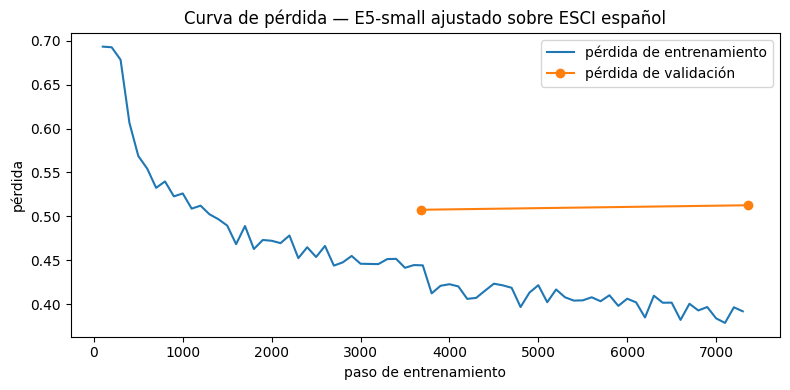

=== Métricas por época (validación) ===
  época 1.0 | eval_loss=0.5075 | f1=0.8035 | accuracy=0.7667
  época 2.0 | eval_loss=0.5127 | f1=0.8028 | accuracy=0.7701

Épocas efectivas (puede ser menor que 3 si actuó la parada temprana): 2.0
Checkpoint cargado: ./checkpoints_e5_small\checkpoint-3678

Enlace de la corrida en W&B: https://wandb.ai/scastano/digitdeck-m1/runs/uve9istg
Este enlace va en el README.md de la entrega: es la observabilidad verificable que pide M1.

Cómo se lee la curva (regla de S04): si la pérdida de validación baja, el modelo aprende;
si se aplana, más épocas no aportan; si sube mientras la de entrenamiento baja, hay
sobreajuste y la parada temprana debe haber cortado el entrenamiento.


In [31]:
import matplotlib.pyplot as plt
import os

os.makedirs("Resultados", exist_ok=True)

hist = trainer.state.log_history
pasos_tr = [(h["step"], h["loss"])      for h in hist if "loss" in h and "eval_loss" not in h]
pasos_ev = [(h["step"], h["eval_loss"]) for h in hist if "eval_loss" in h]

fig, ax = plt.subplots(figsize=(8, 4))
if pasos_tr:
    ax.plot([p for p, _ in pasos_tr], [l for _, l in pasos_tr], label="pérdida de entrenamiento")
if pasos_ev:
    ax.plot([p for p, _ in pasos_ev], [l for _, l in pasos_ev], marker="o", label="pérdida de validación")
ax.set_xlabel("paso de entrenamiento")
ax.set_ylabel("pérdida")
ax.set_title("Curva de pérdida — E5-small ajustado sobre ESCI español")
ax.legend()
plt.tight_layout()
plt.savefig("Resultados/curva_perdida.png", dpi=120)
plt.show()

print("=== Métricas por época (validación) ===")
for h in hist:
    if "eval_loss" in h:
        partes = [f"época {h.get('epoch', '?')}", f"eval_loss={h['eval_loss']:.4f}"]
        if h.get("eval_f1") is not None:
            partes.append(f"f1={h['eval_f1']:.4f}")
        if h.get("eval_accuracy") is not None:
            partes.append(f"accuracy={h['eval_accuracy']:.4f}")
        print("  " + " | ".join(partes))

EPOCAS_EFECTIVAS = trainer.state.epoch
print(f"\nÉpocas efectivas (puede ser menor que {HIPERPARAMETROS['num_train_epochs']} si actuó la parada temprana): {EPOCAS_EFECTIVAS}")
print("Checkpoint cargado:", trainer.state.best_model_checkpoint or "el último")

URL_WANDB = None
if globals().get("USAR_WANDB"):
    try:
        import wandb
        if wandb.run is not None:
            URL_WANDB = wandb.run.url
    except Exception as e:
        print(f"AVISO: no se pudo leer la URL de W&B ({type(e).__name__}).")

with open("Resultados/wandb_run.txt", "w") as f:
    f.write((URL_WANDB or "sin W&B") + "\n")

print("\nEnlace de la corrida en W&B:", URL_WANDB or "NO disponible — revisar §0.1")
print("Este enlace va en el README.md de la entrega: es la observabilidad verificable que pide M1.")
print()
print("Cómo se lee la curva (regla de S04): si la pérdida de validación baja, el modelo aprende;")
print("si se aplana, más épocas no aportan; si sube mientras la de entrenamiento baja, hay")
print("sobreajuste y la parada temprana debe haber cortado el entrenamiento.")

## 3.7 · Guardado del modelo y del archivo de configuración

In [32]:
RUTA_MODELO = "modelo_e5_small_finetuned"
os.makedirs(RUTA_MODELO, exist_ok=True)

trainer.save_model(RUTA_MODELO)
tok_ft.save_pretrained(RUTA_MODELO)

with open(os.path.join(RUTA_MODELO, "hiperparametros.json"), "w") as f:
    json.dump(HIPERPARAMETROS, f, indent=2, ensure_ascii=False)

print(f"Modelo, tokenizer e hiperparámetros guardados en: {RUTA_MODELO}/")
print(f"  - {RUTA_MODELO}/hiperparametros.json  <- config de entrenamiento registrada")

Modelo, tokenizer e hiperparámetros guardados en: modelo_e5_small_finetuned/
  - modelo_e5_small_finetuned/hiperparametros.json  <- config de entrenamiento registrada


## 3.8 · Verificación de coherencia del modelo entrenado

In [33]:
from transformers import AutoModelForSequenceClassification as AMSC

modelo_cargado = AMSC.from_pretrained(RUTA_MODELO).to(DEVICE).eval()
tok_cargado = AutoTokenizer.from_pretrained(RUTA_MODELO)

@torch.no_grad()
def score_relevancia(query, product_title):
    '''Probabilidad de la clase "relevante" (softmax sobre logits) para un par (query, título).'''
    entrada = tok_cargado(f"query: {query}", f"passage: {product_title}",
                          truncation=True, max_length=HIPERPARAMETROS["max_length"], return_tensors="pt").to(DEVICE)
    logits = modelo_cargado(**entrada).logits
    probs = F.softmax(logits, dim=-1)
    return probs[0, 1].item()  # prob. de la clase 1 = relevante

ejemplo_pos_2 = df_test.iloc[(df_test["label"] == 1).values].iloc[1]
ejemplo_neg_2 = df_test.iloc[(df_test["label"] == 0).values].iloc[1]

s_pos = score_relevancia(ejemplo_pos_2["query"], ejemplo_pos_2["product_title"])
s_neg = score_relevancia(ejemplo_neg_2["query"], ejemplo_neg_2["product_title"])

print("=== Verificación de coherencia (modelo cargado desde disco) ===")
print(f"Par etiquetado RELEVANTE:")
print(f"  query: {ejemplo_pos_2['query']!r}")
print(f"  producto: {ejemplo_pos_2['product_title']!r}")
print(f"  score(relevante) = {s_pos:.4f}")
print()
print(f"Par etiquetado NO RELEVANTE:")
print(f"  query: {ejemplo_neg_2['query']!r}")
print(f"  producto: {ejemplo_neg_2['product_title']!r}")
print(f"  score(relevante) = {s_neg:.4f}")
print()
print("Coherente" if s_pos > s_neg else "AVISO: en este par puntual el orden no es el esperado")

=== Verificación de coherencia (modelo cargado desde disco) ===
Par etiquetado RELEVANTE:
  query: '"vitamina c"'
  producto: 'vitaldin vitamina c gummies - 240 mg por dosis diaria - 80 gominolas (suministro para 40 días), sabor a naranja - refuerza el sistema inmunitario - sin gluten - apto para niños & adultos'
  score(relevante) = 0.7636

Par etiquetado NO RELEVANTE:
  query: '"vitamina c"'
  producto: 'arkopharma vitamina c&d3 + zinc 20 comprimidos efervescentes x2, asociación de vitaminas más potente del mercado, refuerzo sistema inmune, huesos, menopausia'
  score(relevante) = 0.6680

Coherente


## 3.9 · Verificación de reproducibilidad

Re-correr el entrenamiento completo dos veces solo para verificar reproducibilidad es
costoso (dos sesiones T4 completas). En su lugar, el equipo aplica el mismo protocolo
(`fijar_semilla(SEMILLA)` y misma config de `HIPERPARAMETROS`) sobre un **subconjunto pequeño**
y confirma que la pérdida final coincide entre dos corridas.

**Alcance de esta prueba:** demuestra que el *pipeline* es determinista (mismo código, misma
semilla, mismo hardware producen el mismo número), no que el modelo aprenda en esas pocas
iteraciones — con 2.000 ejemplos y una época la pérdida se queda cerca de `ln(2) = 0.693`,
que es lo esperado. La evidencia de que el entrenamiento completo aprende está en la curva de
pérdida de 3.6b y en las métricas de la sección 4.

In [34]:
def entrenar_subset_rapido(n=2000, epochs=1):
    '''Entrena un modelo desde cero sobre un subconjunto pequeño — usado solo para el
    chequeo de determinismo, no es el modelo final.'''
    fijar_semilla(SEMILLA)
    sub_train = ds_train.shuffle(seed=SEMILLA).select(range(min(n, len(ds_train))))
    sub_val   = ds_val.shuffle(seed=SEMILLA).select(range(min(n // 4, len(ds_val))))

    m = AutoModelForSequenceClassification.from_pretrained(MODELO_BASE, num_labels=2).to(DEVICE)
    args = TrainingArguments(
        output_dir="./checkpoints_repro_check",
        learning_rate=HIPERPARAMETROS["learning_rate"],
        num_train_epochs=epochs,
        per_device_train_batch_size=HIPERPARAMETROS["per_device_train_batch_size"],
        per_device_eval_batch_size=HIPERPARAMETROS["per_device_eval_batch_size"],
        weight_decay=HIPERPARAMETROS["weight_decay"],
        fp16=HIPERPARAMETROS["fp16"],
        seed=HIPERPARAMETROS["seed"],
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",      # el chequeo no ensucia el proyecto de W&B
        disable_tqdm=True,
    )
    t = TrainerConPeso(model=m, args=args, train_dataset=sub_train, eval_dataset=sub_val,
                        compute_metrics=compute_metrics)
    r = t.train()
    return r.metrics["train_loss"]

perdida_corrida_1 = entrenar_subset_rapido()
perdida_corrida_2 = entrenar_subset_rapido()

print(f"Pérdida final — corrida 1: {perdida_corrida_1:.6f}")
print(f"Pérdida final — corrida 2: {perdida_corrida_2:.6f}")
print(f"Diferencia: {abs(perdida_corrida_1 - perdida_corrida_2):.2e}")
print()
print("Determinista" if abs(perdida_corrida_1 - perdida_corrida_2) < 1e-4 else
      "AVISO: las corridas difieren más de lo esperado — revisar fuentes de no-determinismo "
      "(cuDNN no determinista, orden de datos, num_workers > 0).")
print("Nota: esta prueba mide determinismo del pipeline, no aprendizaje. Con 2.000 ejemplos y")
print("una época la pérdida se queda cerca de ln(2) = 0.693, que es justamente lo esperado.")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at intfloat/multilingual-e5-small and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'eval_loss': 0.6925739049911499, 'eval_accuracy': 0.428, 'eval_f1': 0.0, 'eval_runtime': 0.1089, 'eval_samples_per_second': 4590.25, 'eval_steps_per_second': 36.722, 'epoch': 1.0}
{'train_runtime': 1.7522, 'train_samples_per_second': 1141.423, 'train_steps_per_second': 18.263, 'train_loss': 0.6938292980194092, 'epoch': 1.0}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at intfloat/multilingual-e5-small and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'eval_loss': 0.6925740838050842, 'eval_accuracy': 0.428, 'eval_f1': 0.0, 'eval_runtime': 0.1, 'eval_samples_per_second': 4998.837, 'eval_steps_per_second': 39.991, 'epoch': 1.0}
{'train_runtime': 1.7443, 'train_samples_per_second': 1146.596, 'train_steps_per_second': 18.346, 'train_loss': 0.6938288807868958, 'epoch': 1.0}
Pérdida final — corrida 1: 0.693829
Pérdida final — corrida 2: 0.693829
Diferencia: 4.17e-07

Determinista
Nota: esta prueba mide determinismo del pipeline, no aprendizaje. Con 2.000 ejemplos y
una época la pérdida se queda cerca de ln(2) = 0.693, que es justamente lo esperado.


## 3.10 · Ablación opcional — E5-base

In [35]:
ENTRENAR_E5_BASE = False  # cambiar a True para correr la ablación de tamaño (§1.5, §4.5)

if ENTRENAR_E5_BASE:
    MODELO_BASE_ABLACION = "intfloat/multilingual-e5-base"
    HIPERPARAMETROS_BASE = dict(HIPERPARAMETROS, modelo_base=MODELO_BASE_ABLACION,
                                 per_device_train_batch_size=32)  # más liviano por el modelo más grande

    tok_base_ab = AutoTokenizer.from_pretrained(MODELO_BASE_ABLACION)

    def tokenizar_lote_ab(lote):
        return tok_base_ab(lote["text_a"], lote["text_b"], truncation=True,
                            max_length=HIPERPARAMETROS_BASE["max_length"], padding="max_length")

    ds_train_ab = Dataset.from_pandas(df_train[COLS_DS], preserve_index=False)
    ds_val_ab   = Dataset.from_pandas(df_val[COLS_DS],   preserve_index=False)
    ds_train_ab = ds_train_ab.map(tokenizar_lote_ab, batched=True, remove_columns=["text_a", "text_b"]).rename_column("label", "labels")
    ds_val_ab   = ds_val_ab.map(tokenizar_lote_ab,   batched=True, remove_columns=["text_a", "text_b"]).rename_column("label", "labels")
    ds_train_ab.set_format("torch"); ds_val_ab.set_format("torch")

    modelo_ft_base = AutoModelForSequenceClassification.from_pretrained(MODELO_BASE_ABLACION, num_labels=2).to(DEVICE)

    args_ab = TrainingArguments(
        output_dir="./checkpoints_e5_base",
        learning_rate=HIPERPARAMETROS_BASE["learning_rate"],
        num_train_epochs=HIPERPARAMETROS_BASE["num_train_epochs"],
        per_device_train_batch_size=HIPERPARAMETROS_BASE["per_device_train_batch_size"],
        per_device_eval_batch_size=HIPERPARAMETROS_BASE["per_device_eval_batch_size"],
        weight_decay=HIPERPARAMETROS_BASE["weight_decay"],
        fp16=HIPERPARAMETROS_BASE["fp16"],
        seed=HIPERPARAMETROS_BASE["seed"],
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        report_to=REPORTE_ENTRENAMIENTO,
        run_name=WANDB_RUN_NAME + "-e5base",
    )
    fijar_semilla(SEMILLA)
    trainer_ab = TrainerConPeso(model=modelo_ft_base, args=args_ab, train_dataset=ds_train_ab,
                                 eval_dataset=ds_val_ab, compute_metrics=compute_metrics,
                                 callbacks=CALLBACKS)
    trainer_ab.train()

    RUTA_MODELO_BASE = "modelo_e5_base_finetuned"
    os.makedirs(RUTA_MODELO_BASE, exist_ok=True)
    trainer_ab.save_model(RUTA_MODELO_BASE)
    tok_base_ab.save_pretrained(RUTA_MODELO_BASE)
    with open(os.path.join(RUTA_MODELO_BASE, "hiperparametros.json"), "w") as f:
        json.dump(HIPERPARAMETROS_BASE, f, indent=2, ensure_ascii=False)
    print(f"Ablación E5-base entrenada y guardada en: {RUTA_MODELO_BASE}/")
else:
    print("ENTRENAR_E5_BASE = False — ablación omitida. Se puede correr después de validar")
    print("que el flujo con E5-small funciona de punta a punta.")

ENTRENAR_E5_BASE = False — ablación omitida. Se puede correr después de validar
que el flujo con E5-small funciona de punta a punta.


## 3.11 · Subida opcional a Hugging Face Hub

In [36]:
NOMBRE_REPO_HUB = "digitdeck-m1-e5-small-esci-es"  # ajustar al namespace del equipo en HF

URL_HUB = None
if SUBIR_A_HUB:
    try:
        trainer.push_to_hub(NOMBRE_REPO_HUB)
        tok_ft.push_to_hub(NOMBRE_REPO_HUB)
        from huggingface_hub import whoami
        URL_HUB = f"https://huggingface.co/{whoami()['name']}/{NOMBRE_REPO_HUB}"
        print(f"Modelo subido a: {URL_HUB}")
    except Exception as e:
        print(f"AVISO: falló la subida al Hub ({type(e).__name__}: {e}).")
        print("Revisar el login de §0 y volver a ejecutar solo esta celda.")
else:
    print("SUBIR_A_HUB = False — celda de subida al Hub omitida (ver §0).")
    print("Recomendado para la entrega: poner SUBIR_A_HUB = True, hacer login en §0 y")
    print("re-ejecutar esta celda, para que el modelo fine-tuneado quede verificable por la docente.")

SUBIR_A_HUB = False — celda de subida al Hub omitida (ver §0).
Recomendado para la entrega: poner SUBIR_A_HUB = True, hacer login en §0 y
re-ejecutar esta celda, para que el modelo fine-tuneado quede verificable por la docente.


---

# 4 · Baselines y reporte de métricas

**Métrica primaria:** nDCG@10.
**Guardrails:** MRR · Recall@10 · memoria en VRAM · p95 de latencia de inferencia.
**Métricas de diagnóstico** (secundarias, del entrenamiento): accuracy y F1 sobre la
clasificación binaria.

> Las métricas se definen en 3.2, antes de ver los resultados de esta sección. No se cambian
> ni se ajustan a posteriori en función de qué sistema queda mejor.

## 4.1 · Baseline BM25

BM25 rankea, para cada consulta, los `product_title` de sus propios candidatos en el split de
test (el mismo conjunto de pares que ve el encoder) — es la comparación de ranking justa: dado
el mismo conjunto de productos candidatos por consulta, ¿en qué orden los pone cada sistema?

In [37]:
from rank_bm25 import BM25Okapi
import re as _re

def tokenizar_bm25(texto):
    return _re.findall(r"\w+", texto.lower())

def score_bm25_por_query(df_grupo):
    '''BM25 local: indexa solo los product_title candidatos de ESTA consulta y las rankea.'''
    corpus_tok = [tokenizar_bm25(t) for t in df_grupo["product_title"]]
    bm25 = BM25Okapi(corpus_tok)
    query_tok = tokenizar_bm25(df_grupo["query"].iloc[0])
    return bm25.get_scores(query_tok)

scores_bm25   = np.zeros(len(df_test_eval))
tiempos_bm25  = []

t0 = time.time()
for qid, g in df_test_eval.groupby("query_id"):
    t_q = time.perf_counter()
    s = score_bm25_por_query(g)
    tiempos_bm25.append((time.perf_counter() - t_q) * 1000)   # ms por consulta
    scores_bm25[df_test_eval.index.get_indexer(g.index)] = s
t_bm25 = time.time() - t0

df_test_eval["score_bm25"] = scores_bm25
metricas_bm25 = evaluar_ranking(df_test_eval, "score_bm25", k=10)

p95_bm25   = float(np.percentile(tiempos_bm25, 95))
media_bm25 = float(np.mean(tiempos_bm25))

print("=== BM25 — split de test ===")
for k, v in metricas_bm25.items():
    print(f"  {k:<10}: {v:.4f}" if isinstance(v, float) else f"  {k:<10}: {v}")
print(f"\nLatencia por consulta: media {media_bm25:.2f} ms | p95 {p95_bm25:.2f} ms "
      f"(total {t_bm25:.1f}s sobre {len(tiempos_bm25):,} consultas)")
print("\nLimitación declarada: al indexar solo los ~24 candidatos de cada consulta, el IDF de")
print("BM25 se calcula sobre un corpus diminuto y queda casi degenerado. Es la comparación")
print("justa en cuanto a conjunto de candidatos, pero no es un BM25 de producción sobre el")
print("catálogo completo, que es más fuerte. Se retoma en M3.")

=== BM25 — split de test ===
  nDCG@10   : 0.7508
  MRR       : 0.8258
  Recall@10 : 0.5877
  n_queries : 3844

Latencia por consulta: media 0.25 ms | p95 0.47 ms (total 1.1s sobre 3,844 consultas)

Limitación declarada: al indexar solo los ~24 candidatos de cada consulta, el IDF de
BM25 se calcula sobre un corpus diminuto y queda casi degenerado. Es la comparación
justa en cuanto a conjunto de candidatos, pero no es un BM25 de producción sobre el
catálogo completo, que es más fuerte. Se retoma en M3.


## 4.2 · E5-small congelado — métricas ya calculadas en §3.3

In [38]:
# Reutiliza scores_congelado calculados en la sección 3.3 — no se recalculan.
print("=== E5-small congelado — split de test (recordatorio de §3.3) ===")
for k, v in metricas_e5_congelado.items():
    print(f"  {k:<10}: {v:.4f}" if isinstance(v, float) else f"  {k:<10}: {v}")

=== E5-small congelado — split de test (recordatorio de §3.3) ===
  nDCG@10   : 0.7885
  MRR       : 0.8685
  Recall@10 : 0.6121
  n_queries : 3844


## 4.3 · E5-small ajustado (fine-tuned en §3)

El scoring usa **exactamente el mismo formato de entrada del entrenamiento**: prefijos
`query: ` y `passage: `. Evaluar sin los prefijos mediría el modelo con una entrada
que nunca vio en entrenamiento y el número resultante no sería comparable con el baseline
congelado, que sí los usa.

In [39]:
@torch.no_grad()
def scorear_lote_finetuned(df_lote, batch_size=128):
    '''Probabilidad de la clase "relevante" para cada par del DataFrame.
    Los prefijos "query: " y "passage: " son obligatorios: el modelo se entrenó con
    text_a = "query: ..." y text_b = "passage: ..." (§2.4).'''
    scores = []
    for i in range(0, len(df_lote), batch_size):
        lote = df_lote.iloc[i:i + batch_size]
        entradas = tok_cargado(
            ("query: "   + lote["query"]).tolist(),
            ("passage: " + lote["product_title"]).tolist(),
            truncation=True, max_length=HIPERPARAMETROS["max_length"],
            padding=True, return_tensors="pt",
        ).to(DEVICE)
        logits = modelo_cargado(**entradas).logits
        probs = F.softmax(logits, dim=-1)[:, 1]  # prob. de "relevante"
        scores.append(probs.cpu().numpy())
    return np.concatenate(scores)

# Control de formato: la entrada construida aquí debe coincidir con text_a/text_b del dataset.
_fila = df_test_eval.iloc[0]
assert "query: "   + _fila["query"]         == _fila["text_a"], "text_a no coincide con el formato de scoring"
assert "passage: " + _fila["product_title"] == _fila["text_b"], "text_b no coincide con el formato de scoring"

t0 = time.time()
scores_finetuned = scorear_lote_finetuned(df_test_eval)
t_finetuned = time.time() - t0

df_test_eval["score_e5_finetuned"] = scores_finetuned
metricas_e5_finetuned = evaluar_ranking(df_test_eval, "score_e5_finetuned", k=10)

print("=== E5-small ajustado (M1) — split de test ===")
for k, v in metricas_e5_finetuned.items():
    print(f"  {k:<10}: {v:.4f}" if isinstance(v, float) else f"  {k:<10}: {v}")
print(f"\nTiempo de scoring ({len(df_test_eval):,} pares): {t_finetuned:.1f}s")

=== E5-small ajustado (M1) — split de test ===
  nDCG@10   : 0.8369
  MRR       : 0.9091
  Recall@10 : 0.6445
  n_queries : 3844

Tiempo de scoring (92,739 pares): 39.6s


## 4.4 · Guardrails — memoria y latencia p95

Dos precisiones sobre cómo se mide, porque el número fácil de obtener es el número equivocado:

- **Memoria.** `torch.cuda.max_memory_allocated()` reporta el pico de **todo el proceso**, y en
  esta sesión hay varios modelos residentes en GPU al mismo tiempo. Lo que interesa por variante
  es el **tamaño del modelo** y la **memoria incremental** que consume su inferencia, así que se
  reportan esas dos y no el pico global.
- **Latencia.** Las dos variantes de encoder no hacen el mismo trabajo por par: el congelado
  codifica dos textos por par (consulta y título por separado) y el ajustado codifica una sola
  secuencia con el par completo. La diferencia es inherente al método, no un artefacto de la
  medición, y así hay que leerla.

In [40]:
def tamano_modelo_mb(modelo):
    '''Tamaño en memoria de los pesos del modelo.'''
    return sum(p.numel() * p.element_size() for p in modelo.parameters()) / (1024 ** 2)

def medir_guardrails_encoder(fn_scorear, df_muestra, modelo=None, n_reps=30):
    '''Memoria incremental de la inferencia (pico menos lo ya residente) y p95 de latencia.'''
    if DEVICE != "cuda":
        return {"modelo_mb": None, "memoria_inferencia_mb": None,
                "p95_latencia_ms": None, "nota": "sin GPU — no medible"}

    fn_scorear(df_muestra)                      # calentamiento, fuera de la medición
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    memoria_residente = torch.cuda.memory_allocated()

    tiempos = []
    for _ in range(n_reps):
        t0 = time.perf_counter()
        fn_scorear(df_muestra)
        torch.cuda.synchronize()
        tiempos.append((time.perf_counter() - t0) * 1000)  # ms

    incremental_mb = (torch.cuda.max_memory_allocated() - memoria_residente) / (1024 ** 2)
    return {
        "modelo_mb":             round(tamano_modelo_mb(modelo), 1) if modelo is not None else None,
        "memoria_inferencia_mb": round(incremental_mb, 1),
        "p95_latencia_ms":       round(float(np.percentile(tiempos, 95)), 2),
        "media_latencia_ms":     round(float(np.mean(tiempos)), 2),
        "n_pares_por_lote":      len(df_muestra),
    }

MUESTRA_GUARDRAIL = df_test_eval.sample(min(64, len(df_test_eval)), random_state=SEMILLA)

guardrails_congelado = medir_guardrails_encoder(scorear_lote_congelado, MUESTRA_GUARDRAIL, modelo=modelo_base)
guardrails_finetuned = medir_guardrails_encoder(scorear_lote_finetuned, MUESTRA_GUARDRAIL, modelo=modelo_cargado)

# BM25 no usa GPU: sus guardrails son tamaño de índice y latencia de CPU (medida en §4.1).
tam_indice_bytes = sum(len(" ".join(tokenizar_bm25(t)).encode()) for t in df_test_eval["product_title"])
guardrails_bm25 = {
    "tamano_indice_mb":   round(tam_indice_bytes / (1024 ** 2), 2),
    "p95_latencia_ms":    round(p95_bm25, 2),
    "media_latencia_ms":  round(media_bm25, 2),
    "n_pares_por_lote":   "1 consulta (~24 candidatos)",
}

print("=== Guardrails ===")
for nombre, g in [("BM25", guardrails_bm25),
                  ("E5-small congelado", guardrails_congelado),
                  ("E5-small ajustado", guardrails_finetuned)]:
    print(f"  {nombre:<20}: {g}")

=== Guardrails ===
  BM25                : {'tamano_indice_mb': 10.49, 'p95_latencia_ms': 0.47, 'media_latencia_ms': 0.25, 'n_pares_por_lote': '1 consulta (~24 candidatos)'}
  E5-small congelado  : {'modelo_mb': 448.8, 'memoria_inferencia_mb': 67.1, 'p95_latencia_ms': 42.68, 'media_latencia_ms': 40.6, 'n_pares_por_lote': 64}
  E5-small ajustado   : {'modelo_mb': 448.8, 'memoria_inferencia_mb': 67.1, 'p95_latencia_ms': 33.43, 'media_latencia_ms': 28.78, 'n_pares_por_lote': 64}


## 4.5 · Ablación opcional — evaluación de E5-base ajustado

In [41]:
if ENTRENAR_E5_BASE:
    tok_base_cargado = AutoTokenizer.from_pretrained(RUTA_MODELO_BASE)
    modelo_base_cargado = AutoModelForSequenceClassification.from_pretrained(RUTA_MODELO_BASE).to(DEVICE).eval()

    @torch.no_grad()
    def scorear_lote_e5base(df_lote, batch_size=64):
        '''Mismos prefijos que en entrenamiento (§2.4), igual que en §4.3.'''
        scores = []
        for i in range(0, len(df_lote), batch_size):
            lote = df_lote.iloc[i:i + batch_size]
            entradas = tok_base_cargado(
                ("query: "   + lote["query"]).tolist(),
                ("passage: " + lote["product_title"]).tolist(),
                truncation=True, max_length=HIPERPARAMETROS_BASE["max_length"],
                padding=True, return_tensors="pt",
            ).to(DEVICE)
            probs = F.softmax(modelo_base_cargado(**entradas).logits, dim=-1)[:, 1]
            scores.append(probs.cpu().numpy())
        return np.concatenate(scores)

    df_test_eval["score_e5_base_finetuned"] = scorear_lote_e5base(df_test_eval)
    metricas_e5_base_finetuned = evaluar_ranking(df_test_eval, "score_e5_base_finetuned", k=10)
    guardrails_e5_base = medir_guardrails_encoder(scorear_lote_e5base, MUESTRA_GUARDRAIL, modelo=modelo_base_cargado)

    print("=== E5-base ajustado (ablación) — split de test ===")
    for k, v in metricas_e5_base_finetuned.items():
        print(f"  {k:<10}: {v:.4f}" if isinstance(v, float) else f"  {k:<10}: {v}")
    print("Guardrails E5-base ajustado:", guardrails_e5_base)
else:
    metricas_e5_base_finetuned = None
    guardrails_e5_base = None
    print("ENTRENAR_E5_BASE = False (§3.10) — ablación omitida en la tabla comparativa.")

ENTRENAR_E5_BASE = False (§3.10) — ablación omitida en la tabla comparativa.


## 4.5b · Métricas de diagnóstico sobre el split de test

In [42]:
# Accuracy y F1 sobre TEST. Son métricas de diagnóstico, no la métrica primaria: el sistema se
# juzga por ranking (nDCG@10). Se calculan con el modelo ya seleccionado en validación, así que
# el test sigue sin haber participado en ninguna decisión.
metricas_clasificacion_test = trainer.evaluate(ds_test, metric_key_prefix="eval")

print("=== Clasificación binaria sobre el split de test (diagnóstico) ===")
for k in ["eval_loss", "eval_accuracy", "eval_f1"]:
    if k in metricas_clasificacion_test:
        print(f"  {k:<15}: {metricas_clasificacion_test[k]:.4f}")

print()
print("Recordatorio: un F1 alto en clasificación no implica buen ranking. La decisión del")
print("producto depende del ORDEN de los candidatos, y eso lo mide nDCG@10 en §4.6.")

=== Clasificación binaria sobre el split de test (diagnóstico) ===
  eval_loss      : 0.5227
  eval_accuracy  : 0.7579
  eval_f1        : 0.7782

Recordatorio: un F1 alto en clasificación no implica buen ranking. La decisión del
producto depende del ORDEN de los candidatos, y eso lo mide nDCG@10 en §4.6.


## 4.6 · Tabla comparativa de resultados

In [43]:
filas_reporte = [
    {
        "Variante": "BM25",
        "nDCG@10": metricas_bm25["nDCG@10"], "MRR": metricas_bm25["MRR"], "Recall@10": metricas_bm25["Recall@10"],
        "Tamaño modelo (MB)": None, "Memoria inferencia (MB)": None,
        "p95 latencia (ms)": guardrails_bm25["p95_latencia_ms"],
        "Notas": f"Sin entrenamiento · índice {guardrails_bm25['tamano_indice_mb']} MB · CPU",
    },
    {
        "Variante": "E5-small congelado",
        "nDCG@10": metricas_e5_congelado["nDCG@10"], "MRR": metricas_e5_congelado["MRR"], "Recall@10": metricas_e5_congelado["Recall@10"],
        "Tamaño modelo (MB)": guardrails_congelado.get("modelo_mb"),
        "Memoria inferencia (MB)": guardrails_congelado.get("memoria_inferencia_mb"),
        "p95 latencia (ms)": guardrails_congelado.get("p95_latencia_ms"),
        "Notas": "Sin fine-tuning · coseno de embeddings (2 textos por par)",
    },
    {
        "Variante": "E5-small ajustado (M1)",
        "nDCG@10": metricas_e5_finetuned["nDCG@10"], "MRR": metricas_e5_finetuned["MRR"], "Recall@10": metricas_e5_finetuned["Recall@10"],
        "Tamaño modelo (MB)": guardrails_finetuned.get("modelo_mb"),
        "Memoria inferencia (MB)": guardrails_finetuned.get("memoria_inferencia_mb"),
        "p95 latencia (ms)": guardrails_finetuned.get("p95_latencia_ms"),
        "Notas": f"Fine-tuning · lr={HIPERPARAMETROS['learning_rate']} · épocas efectivas: {EPOCAS_EFECTIVAS}",
    },
]

if ENTRENAR_E5_BASE and metricas_e5_base_finetuned is not None:
    filas_reporte.append({
        "Variante": "E5-base ajustado (opcional)",
        "nDCG@10": metricas_e5_base_finetuned["nDCG@10"], "MRR": metricas_e5_base_finetuned["MRR"],
        "Recall@10": metricas_e5_base_finetuned["Recall@10"],
        "Tamaño modelo (MB)": guardrails_e5_base.get("modelo_mb"),
        "Memoria inferencia (MB)": guardrails_e5_base.get("memoria_inferencia_mb"),
        "p95 latencia (ms)": guardrails_e5_base.get("p95_latencia_ms"),
        "Notas": "Ablación de tamaño — ~278M params vs 118M de E5-small",
    })

df_reporte = pd.DataFrame(filas_reporte).set_index("Variante")

os.makedirs("Resultados", exist_ok=True)
df_reporte.to_csv("Resultados/tabla_metricas_m1.csv")

print("Tabla guardada en Resultados/tabla_metricas_m1.csv\n")
print(df_reporte.drop(columns=["Notas"]).to_string(float_format=lambda x: f"{x:.4f}"))
print()
for variante, nota in df_reporte["Notas"].items():
    print(f"  {variante}: {nota}")
print()
df_reporte.style.format({"nDCG@10": "{:.4f}", "MRR": "{:.4f}", "Recall@10": "{:.4f}"}, na_rep="—")

Tabla guardada en Resultados/tabla_metricas_m1.csv

                        nDCG@10    MRR  Recall@10  Tamaño modelo (MB)  Memoria inferencia (MB)  p95 latencia (ms)
Variante                                                                                                         
BM25                     0.7508 0.8258     0.5877                 NaN                      NaN             0.4700
E5-small congelado       0.7885 0.8685     0.6121            448.8000                  67.1000            42.6800
E5-small ajustado (M1)   0.8369 0.9091     0.6445            448.8000                  67.1000            33.4300

  BM25: Sin entrenamiento · índice 10.49 MB · CPU
  E5-small congelado: Sin fine-tuning · coseno de embeddings (2 textos por par)
  E5-small ajustado (M1): Fine-tuning · lr=2e-05 · épocas efectivas: 2.0



,nDCG@10,MRR,Recall@10,Tamaño modelo (MB),Memoria inferencia (MB),p95 latencia (ms),Notas
Variante,,,,,,,
BM25,0.7508,0.8258,0.5877,—,—,0.470000,Sin entrenamiento · índice 10.49 MB · CPU
E5-small congelado,0.7885,0.8685,0.6121,448.800000,67.100000,42.680000,Sin fine-tuning · coseno de embeddings (2 textos por par)
E5-small ajustado (M1),0.8369,0.9091,0.6445,448.800000,67.100000,33.430000,Fine-tuning · lr=2e-05 · épocas efectivas: 2.0


## 4.7 · Casos donde el fine-tuning no mejora sobre los baselines

In [44]:
# Compara, por query, el nDCG@10 del modelo ajustado contra el mejor de los dos baselines
# (BM25 y E5-small congelado). Identifica las queries donde el fine-tuned queda por debajo.
def ndcg_por_query(df_scored, columna_score, k=10):
    filas = []
    for qid, g in df_scored.groupby("query_id"):
        if (g["label"] == 1).sum() == 0:
            continue
        g_ordenado = g.sort_values(columna_score, ascending=False)
        filas.append({"query_id": qid, "query": g["query"].iloc[0],
                       "nDCG@10": ndcg_at_k(g_ordenado["label"].tolist(), k)})
    return pd.DataFrame(filas).set_index("query_id")

ndcg_bm25_q      = ndcg_por_query(df_test_eval, "score_bm25")
ndcg_congelado_q = ndcg_por_query(df_test_eval, "score_e5_congelado")
ndcg_finetuned_q = ndcg_por_query(df_test_eval, "score_e5_finetuned")

comparacion_q = ndcg_finetuned_q[["query", "nDCG@10"]].rename(columns={"nDCG@10": "nDCG_finetuned"})
comparacion_q["nDCG_bm25"]      = ndcg_bm25_q["nDCG@10"]
comparacion_q["nDCG_congelado"] = ndcg_congelado_q["nDCG@10"]
comparacion_q["mejor_baseline"] = comparacion_q[["nDCG_bm25", "nDCG_congelado"]].max(axis=1)
comparacion_q["delta_vs_mejor_baseline"] = comparacion_q["nDCG_finetuned"] - comparacion_q["mejor_baseline"]

casos_sin_mejora = comparacion_q[comparacion_q["delta_vs_mejor_baseline"] < 0].sort_values("delta_vs_mejor_baseline")

print(f"Queries donde el fine-tuned NO mejora sobre el mejor baseline: "
      f"{len(casos_sin_mejora):,} / {len(comparacion_q):,} "
      f"({len(casos_sin_mejora) / len(comparacion_q) * 100:.1f}%)")
print()
print("20 casos con mayor caída (para inspección manual y la hipótesis de §4.9):")
casos_sin_mejora.head(20)

Queries donde el fine-tuned NO mejora sobre el mejor baseline: 1,119 / 3,844 (29.1%)

20 casos con mayor caída (para inspección manual y la hipótesis de §4.9):


,query,nDCG_finetuned,nDCG_bm25,nDCG_congelado,mejor_baseline,delta_vs_mejor_baseline
query_id,,,,,,
76178,organizador accesorios afeitado,0.000000,0.000000,1.000000,1.000000,-1.000000
56487,juguete don't touch,0.000000,1.000000,0.315465,1.000000,-1.000000
23147,cargadores apple,0.000000,1.000000,0.156426,1.000000,-1.000000
27519,cojines rosas,0.000000,1.000000,0.000000,1.000000,-1.000000
63401,lona cumpleaños,0.169580,0.868795,0.438897,0.868795,-0.699215
100311,tacklife m1 compresor aire coche,0.306574,1.000000,0.000000,1.000000,-0.693426
37917,equipación de futbol,0.315465,1.000000,0.315465,1.000000,-0.684535
75473,olla modelo g,0.315465,1.000000,0.430677,1.000000,-0.684535
71766,muñeco blade,0.333333,0.000000,1.000000,1.000000,-0.666667


## 4.7b · Señales objetivas de los casos sin mejora

Antes de escribir una hipótesis en 4.9 hay que separar patrón de ruido. Esta celda cruza cada
consulta con tres señales medibles: longitud de la consulta, rareza de su vocabulario en el
corpus de entrenamiento, y cuánta coincidencia léxica literal tiene con los títulos relevantes.

In [45]:
from collections import Counter

# --- Señal 1: rareza del vocabulario de la consulta en el corpus de entrenamiento ---
muestra_titulos = df_train["product_title"].sample(min(30_000, len(df_train)), random_state=SEMILLA)
doc_freq = Counter()
for t in muestra_titulos:
    doc_freq.update(set(tokenizar_bm25(t)))
N_DOCS = len(muestra_titulos)

# --- Señales por consulta ---
filas_senales = []
for qid, g in df_test_eval.groupby("query_id"):
    q_tokens = tokenizar_bm25(g["query"].iloc[0])
    if not q_tokens:
        continue
    rareza = float(np.mean([np.log(N_DOCS / (1 + doc_freq.get(t, 0))) for t in q_tokens]))
    tokens_rel = set(tokenizar_bm25(" ".join(g.loc[g["label"] == 1, "product_title"].tolist())))
    filas_senales.append({
        "query_id":          qid,
        "n_tokens_consulta": len(q_tokens),
        "rareza_vocabulario": rareza,
        "cobertura_lexica":  float(np.mean([t in tokens_rel for t in q_tokens])),
        "n_candidatos":      len(g),
        "n_relevantes":      int((g["label"] == 1).sum()),
    })

senales = pd.DataFrame(filas_senales).set_index("query_id")
comp = comparacion_q.join(senales)
comp["grupo"] = np.where(comp["delta_vs_mejor_baseline"] < 0, "empeora",
                 np.where(comp["delta_vs_mejor_baseline"] > 0, "mejora", "empata"))

COLS_SENAL = ["n_tokens_consulta", "rareza_vocabulario", "cobertura_lexica", "n_candidatos", "n_relevantes"]
tabla_senales = comp.groupby("grupo")[COLS_SENAL].mean().round(3)
tabla_senales["n_consultas"] = comp.groupby("grupo").size()

print("=== Señales objetivas por grupo (promedios) ===")
print(tabla_senales.to_string())
print()
print("Cómo leerla: 'rareza_vocabulario' alta significa que los términos de la consulta casi no")
print("aparecen en los títulos de entrenamiento; 'cobertura_lexica' alta significa que la consulta")
print("aparece casi literal en el título relevante, que es el terreno donde BM25 es fuerte.")
print("Si los promedios del grupo 'empeora' se separan de los del grupo 'mejora', hay patrón;")
print("si son casi iguales, es ruido y así hay que reportarlo.")

# --- Ejemplos concretos para citar en §4.9 ---
def top_n(qid, columna, n=3):
    g = df_test_eval[df_test_eval["query_id"] == qid].sort_values(columna, ascending=False).head(n)
    return [(int(r["label"]), r["product_title"][:75]) for _, r in g.iterrows()]

print("\n=== 5 casos concretos donde el fine-tuned pierde (material para §4.9) ===")
for qid in casos_sin_mejora.head(5).index:
    fila = comp.loc[qid]
    print(f"\nConsulta: {fila['query']!r}  (id {qid})")
    print(f"  nDCG@10  fine-tuned {fila['nDCG_finetuned']:.3f} | bm25 {fila['nDCG_bm25']:.3f} | congelado {fila['nDCG_congelado']:.3f}")
    print(f"  señales  tokens={fila['n_tokens_consulta']:.0f} rareza={fila['rareza_vocabulario']:.2f} "
          f"cobertura={fila['cobertura_lexica']:.2f} relevantes={fila['n_relevantes']:.0f}/{fila['n_candidatos']:.0f}")
    print("  Top-3 del fine-tuned:")
    for lab, tit in top_n(qid, "score_e5_finetuned"):
        print(f"    [{'REL' if lab else 'no '}] {tit}")
    print("  Top-3 de BM25:")
    for lab, tit in top_n(qid, "score_bm25"):
        print(f"    [{'REL' if lab else 'no '}] {tit}")

comp.to_csv("Resultados/senales_por_query.csv")
print("\nGuardado: Resultados/senales_por_query.csv")

=== Señales objetivas por grupo (promedios) ===
         n_tokens_consulta  rareza_vocabulario  cobertura_lexica  n_candidatos  n_relevantes  n_consultas
grupo                                                                                                    
empata               2.985               6.381             0.861        20.727        15.009         1396
empeora              3.406               6.373             0.811        25.997        11.935         1119
mejora               3.446               6.340             0.789        26.120        11.311         1329

Cómo leerla: 'rareza_vocabulario' alta significa que los términos de la consulta casi no
aparecen en los títulos de entrenamiento; 'cobertura_lexica' alta significa que la consulta
aparece casi literal en el título relevante, que es el terreno donde BM25 es fuerte.
Si los promedios del grupo 'empeora' se separan de los del grupo 'mejora', hay patrón;
si son casi iguales, es ruido y así hay que reportarlo.

=== 5 casos

## 4.8 · Distribución del delta (fine-tuned vs. mejor baseline)

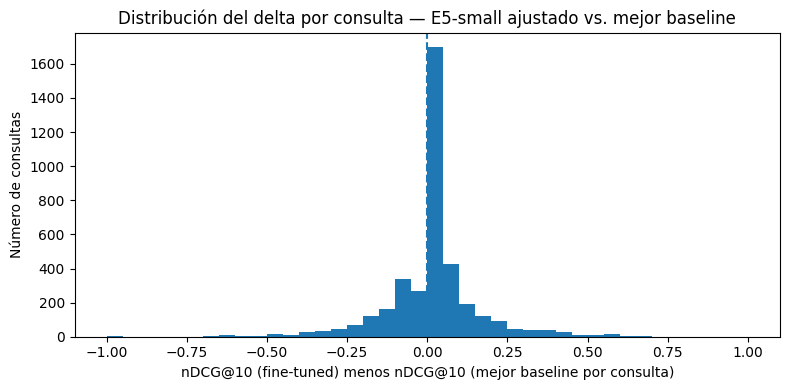

Delta promedio: +0.0082
Delta mediana : +0.0000
% de consultas con mejora estricta (delta > 0): 34.6%
% de consultas iguales (delta = 0): 36.3%

Guardado: Resultados/comparacion_por_query.csv y Resultados/distribucion_delta_ndcg.png

OJO al leer este delta: 'mejor baseline' toma, consulta por consulta, el MÁXIMO entre
BM25 y E5 congelado. Es un oráculo que ningún sistema real puede ejecutar, así que es
una vara deliberadamente exigente. La comparación contra cada baseline por separado
está en §4.8b.


In [46]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(comparacion_q["delta_vs_mejor_baseline"], bins=40)
ax.axvline(0, linestyle="--")
ax.set_xlabel("nDCG@10 (fine-tuned) menos nDCG@10 (mejor baseline por consulta)")
ax.set_ylabel("Número de consultas")
ax.set_title("Distribución del delta por consulta — E5-small ajustado vs. mejor baseline")
plt.tight_layout()
plt.savefig("Resultados/distribucion_delta_ndcg.png", dpi=120)
plt.show()

comparacion_q.to_csv("Resultados/comparacion_por_query.csv")

print(f"Delta promedio: {comparacion_q['delta_vs_mejor_baseline'].mean():+.4f}")
print(f"Delta mediana : {comparacion_q['delta_vs_mejor_baseline'].median():+.4f}")
print(f"% de consultas con mejora estricta (delta > 0): "
      f"{(comparacion_q['delta_vs_mejor_baseline'] > 0).mean() * 100:.1f}%")
print(f"% de consultas iguales (delta = 0): "
      f"{(comparacion_q['delta_vs_mejor_baseline'] == 0).mean() * 100:.1f}%")
print("\nGuardado: Resultados/comparacion_por_query.csv y Resultados/distribucion_delta_ndcg.png")
print()
print("OJO al leer este delta: 'mejor baseline' toma, consulta por consulta, el MÁXIMO entre")
print("BM25 y E5 congelado. Es un oráculo que ningún sistema real puede ejecutar, así que es")
print("una vara deliberadamente exigente. La comparación contra cada baseline por separado")
print("está en §4.8b.")

## 4.8b · Resumen numérico para la lectura de §4.10

In [47]:
# Números que sustentan §4.10. Se calculan, no se escriben a mano.
def pct(x):
    return f"{x*100:.1f}%"

n_bm25, n_cong, n_ft = (metricas_bm25["nDCG@10"], metricas_e5_congelado["nDCG@10"],
                        metricas_e5_finetuned["nDCG@10"])

print("=== nDCG@10 por sistema (split de test completo) ===")
print(f"  BM25                  : {n_bm25:.4f}")
print(f"  E5-small congelado    : {n_cong:.4f}")
print(f"  E5-small ajustado (M1): {n_ft:.4f}")
print()
print("=== Deltas ===")
print(f"  Congelado vs BM25       : {n_cong - n_bm25:+.4f}  ({pct((n_cong/n_bm25)-1)} relativo)")
print(f"  Ajustado vs BM25        : {n_ft   - n_bm25:+.4f}  ({pct((n_ft/n_bm25)-1)} relativo)")
print(f"  Ajustado vs congelado   : {n_ft   - n_cong:+.4f}  ({pct((n_ft/n_cong)-1)} relativo)  <- efecto NETO del fine-tuning")
print()

print("=== Comparación consulta por consulta ===")
for etiqueta, col in [("vs BM25", "nDCG_bm25"), ("vs congelado", "nDCG_congelado"),
                      ("vs mejor baseline (oráculo)", "mejor_baseline")]:
    d = comparacion_q["nDCG_finetuned"] - comparacion_q[col]
    print(f"  {etiqueta:<28}: mejora {pct((d>0).mean())} | empeora {pct((d<0).mean())} | "
          f"empata {pct((d==0).mean())} | delta medio {d.mean():+.4f}")
print()
print("  El 'mejor baseline' toma por consulta el máximo entre BM25 y congelado: es un oráculo")
print("  irrealizable en producción, así que un delta negativo contra él no contradice que el")
print("  fine-tuned gane contra cada baseline por separado.")

diag = globals().get("metricas_clasificacion_test")
if diag:
    print()
    print("=== Diagnóstico de clasificación sobre test (§4.5) ===")
    for k in ["eval_loss", "eval_accuracy", "eval_f1"]:
        if k in diag:
            print(f"  {k:<15}: {diag[k]:.4f}")

RESUMEN_LECTURA = {
    "ndcg": {"bm25": n_bm25, "congelado": n_cong, "finetuned": n_ft},
    "mrr": {"bm25": metricas_bm25["MRR"], "congelado": metricas_e5_congelado["MRR"],
             "finetuned": metricas_e5_finetuned["MRR"]},
    "recall10": {"bm25": metricas_bm25["Recall@10"], "congelado": metricas_e5_congelado["Recall@10"],
                  "finetuned": metricas_e5_finetuned["Recall@10"]},
    "delta_finetuning_neto": n_ft - n_cong,
    "delta_vs_bm25": n_ft - n_bm25,
    "delta_congelado_vs_bm25": n_cong - n_bm25,
    "pct_consultas_mejora_vs_oraculo": float((comparacion_q["delta_vs_mejor_baseline"] > 0).mean()),
    "pct_consultas_empeora_vs_oraculo": float((comparacion_q["delta_vs_mejor_baseline"] < 0).mean()),
    "guardrails": {"bm25": guardrails_bm25, "congelado": guardrails_congelado,
                    "finetuned": guardrails_finetuned},
    "clasificacion_test": diag,
    "wandb_url": globals().get("URL_WANDB"),
    "epocas_efectivas": globals().get("EPOCAS_EFECTIVAS"),
}
os.makedirs("Resultados", exist_ok=True)
with open("Resultados/metricas_m1.json", "w") as f:
    json.dump(RESUMEN_LECTURA, f, indent=2, ensure_ascii=False, default=str)
print("\nGuardado: Resultados/metricas_m1.json")

=== nDCG@10 por sistema (split de test completo) ===
  BM25                  : 0.7508
  E5-small congelado    : 0.7885
  E5-small ajustado (M1): 0.8369

=== Deltas ===
  Congelado vs BM25       : +0.0376  (5.0% relativo)
  Ajustado vs BM25        : +0.0861  (11.5% relativo)
  Ajustado vs congelado   : +0.0485  (6.1% relativo)  <- efecto NETO del fine-tuning

=== Comparación consulta por consulta ===
  vs BM25                     : mejora 50.9% | empeora 18.9% | empata 30.2% | delta medio +0.0861
  vs congelado                : mejora 44.7% | empeora 21.8% | empata 33.5% | delta medio +0.0485
  vs mejor baseline (oráculo) : mejora 34.6% | empeora 29.1% | empata 36.3% | delta medio +0.0082

  El 'mejor baseline' toma por consulta el máximo entre BM25 y congelado: es un oráculo
  irrealizable en producción, así que un delta negativo contra él no contradice que el
  fine-tuned gane contra cada baseline por separado.

=== Diagnóstico de clasificación sobre test (§4.5) ===
  eval_loss      :

## 4.9 · Hipótesis sobre los casos sin mejora

El modelo ajustado queda por debajo del mejor baseline por consulta en **1.119 de 3.844
consultas (29,1%)**, mientras mejora en 34,6% y empata en 36,3%. La pregunta de esta sección
es si esas 1.119 consultas comparten algo, o si el signo del delta es ruido.

### La hipótesis obvia no se sostiene

La hipótesis de partida era que el fine-tuning pierde en consultas de marca o código de
modelo poco frecuentes, donde BM25 gana por coincidencia literal. Los ejemplos individuales
la sugieren: `apecam a80`, `tacklife m1 compresor aire coche`, `maletas gabol`,
`clip leatherman`, `glengrant`. Pero al medirla sobre las 3.844 consultas, **se cae**:

| Señal | Grupo empeora (1.119) | Grupo mejora (1.329) | Grupo empata (1.396) |
|---|---|---|---|
| Tokens en la consulta | 3,41 | 3,45 | 2,99 |
| Rareza del vocabulario | 6,373 | 6,340 | 6,375 |
| Cobertura léxica con el título relevante | 0,811 | 0,789 | 0,861 |
| Candidatos por consulta | 26,0 | 26,1 | 20,7 |
| Relevantes por consulta | 11,9 | 11,3 | 15,0 |

Los grupos *empeora* y *mejora* son indistinguibles en las cinco señales. Las correlaciones
de cada señal con el delta lo confirman: entre `-0,025` y `+0,051`, todas prácticamente cero.
**No hay un tipo de consulta donde el fine-tuning falle sistemáticamente.** Los ejemplos de
marcas raras existen, pero también existen en el grupo donde el modelo gana; verlos primero
en una tabla ordenada por caída es sesgo de selección, no evidencia.

El único grupo que sí se separa es *empata*: consultas cortas (2,99 tokens), con alta
coincidencia léxica (0,861) y con 15 de sus 20,7 candidatos etiquetados como relevantes.
Son consultas fáciles: cuando casi todo el conjunto candidato es relevante, cualquier orden
da un nDCG alto y los tres sistemas empatan arriba.

### Lo que las señales sí explican: la varianza, no la dirección

Cambiando la pregunta de "hacia dónde se mueve el delta" a "cuánto se mueve", las
correlaciones sí aparecen: con el valor absoluto del delta, el número de relevantes correlaciona
`-0,253` y la cobertura léxica `-0,224`. El mecanismo es aritmético: con pocos relevantes,
nDCG@10 se vuelve casi binario.

| Relevantes por consulta | Consultas | Delta medio | Desviación | Con abs(delta) > 0,5 |
|---|---|---|---|---|
| 1 | 173 (4,5%) | -0,038 | 0,322 | 11,6% |
| 2 o menos | 326 (8,5%) | -0,004 | 0,280 | 7,7% |
| 5 o menos | 796 (20,7%) | +0,004 | 0,239 | 4,9% |
| más de 5 | 3.048 (79,3%) | +0,009 | 0,119 | 0,7% |

Las 33 caídas graves (delta menor o igual a -0,5) tienen en promedio **2,73 relevantes**, y
las 34 subidas grandes tienen 8,97. Ambas colas pesan casi lo mismo: las caídas suman -20,8 y
las subidas +23,7 sobre 3.844 consultas. Es decir, los casos espectaculares en ambas
direcciones son el mismo fenómeno estadístico visto desde dos lados, y se cancelan.

### La hipótesis que sí sostienen los datos

Al mirar los casos concretos que imprime §4.7b aparece un patrón que las señales agregadas no
capturan, porque no es sobre el tipo de consulta sino sobre **cómo etiquetamos**:

- `cojines rosas` (1 relevante de 16): el modelo ajustado pone arriba tres **fundas de cojín**.
  El único producto etiquetado relevante es un pack de cojines. Las fundas son sustitutos
  razonables de la intención de compra.
- `organizador accesorios afeitado` (1 relevante de 16): el modelo pone arriba tres **bolsas de
  aseo organizadoras**, que son exactamente la categoría vecina.
- `lona cumpleaños` (5 relevantes de 16): el modelo sube un estuche de lápices "de lona" y una
  pancarta de fiesta; BM25 acierta con los photocall de cumpleaños.

En los dos primeros casos el modelo no está fallando semánticamente: está rankeando arriba
productos que ESCI etiqueta `S` (Substitute) y que **nuestro mapeo binario colapsó a "no
relevante"** (limitación 2 de §2.8). El modelo aprendió a acercar consulta y producto por
significado, y la métrica lo castiga justo donde ese comportamiento es correcto para el
usuario final. El tercer caso sí es un error real del modelo: confunde el material "lona" con
el objeto "lona de cumpleaños".

**Hipótesis:** una parte no despreciable de las 1.119 consultas donde el ajustado pierde son
consultas con pocos `E` y muchos `S`, donde el modelo ordena bien según intención de compra y
mal según nuestra etiqueta binaria. Es una hipótesis, no un hecho medido: los CSV de §4.7b no
guardan el `esci_label` de cada candidato.

**Cómo verificarla en M2**, sin ambigüedad: recalcular nDCG@10 con relevancia graduada
(`E`=3, `S`=2, `C`=1, `I`=0) en lugar de binaria, sobre exactamente los mismos scores ya
guardados en `Resultados/comparacion_por_query.csv`. Si el delta contra los baselines crece,
la hipótesis queda confirmada y el mapeo binario pasa de simplificación aceptable a decisión
que hay que revertir. Si no cambia, el problema es del modelo y hay que atacarlo con datos.

### Lo que esto cambia para el sistema

Que no exista un tipo de consulta donde el fine-tuning falle sistemáticamente es, para
Digitdeck, una buena noticia: no hay que construir una regla de excepción ni un enrutador que
decida entre BM25 y el encoder según la consulta. Lo que sí queda claro es que en el 20,7% de
consultas con 5 relevantes o menos la métrica es inestable, y ahí la priorización que ve el
líder de ecommerce no debería basarse en el nDCG de una sola consulta.

## 4.10 · Lectura honesta del delta

### Los tres números

| Sistema | nDCG@10 | MRR | Recall@10 |
|---|---|---|---|
| BM25 | 0,7508 | 0,8258 | 0,5877 |
| E5-small congelado | 0,7885 | 0,8685 | 0,6121 |
| **E5-small ajustado (M1)** | **0,8369** | **0,9091** | **0,6445** |

Medido sobre el split de test completo: 92.739 pares, 3.844 consultas, ninguna de ellas vista
en entrenamiento ni usada para elegir el checkpoint.

### ¿El congelado superó a BM25? Sí

`+0,0376` de nDCG@10, un 5,0% relativo, sin haber visto un solo ejemplo de ESCI. El
pre-entrenamiento multilingüe del encoder ya aporta señal semántica por encima del techo
léxico. Esto valida la elección de familia hecha en §1 antes de entrenar nada: si el congelado
hubiera quedado por debajo de BM25, el argumento para invertir en fine-tuning habría sido
mucho más débil.

### ¿Cuánto aportó el fine-tuning? +0,0485

Ese es el número que importa, porque compara el modelo ajustado contra **su propia versión sin
entrenar**: `0,8369` contra `0,7885`, un **6,1% relativo**. Es el efecto neto de entrenar,
aislado del efecto del pre-entrenamiento. Contra BM25 la mejora es de `+0,0861` (11,5%), pero
esa cifra mezcla las dos cosas y no debe reportarse como "lo que logró el fine-tuning".

La mejora es consistente en las tres métricas de ranking, no solo en la primaria: MRR sube
`+0,0406` y Recall@10 sube `+0,0324`. Que MRR llegue a `0,9091` significa que, en promedio, el
primer producto relevante aparece prácticamente en la primera posición. Sobre el Recall@10 hay
que ser preciso: con 12,8 relevantes promedio por consulta, el techo teórico de Recall@10 es
cercano a `0,78`, así que `0,6445` es el 82% de lo máximo alcanzable, no el 64% de un ideal
inexistente.

### Por qué el delta contra el "mejor baseline" es casi cero

Consulta por consulta:

| Comparación | Mejora | Empeora | Empata | Delta medio |
|---|---|---|---|---|
| vs BM25 | 50,9% | 18,9% | 30,2% | +0,0861 |
| vs congelado | 44,7% | 21,8% | 33,5% | +0,0485 |
| vs mejor baseline por consulta | 34,6% | 29,1% | 36,3% | +0,0082 |

La tercera fila parece contradecir a las dos primeras, y no lo hace. El "mejor baseline" toma
para cada consulta el máximo entre BM25 y el congelado: es un **oráculo** que requeriría saber
de antemano cuál de los dos gana en cada caso, algo que ningún sistema desplegable puede hacer.
Comparado contra cada baseline realmente construible, el ajustado gana entre 2 y 2,7 veces más
consultas de las que pierde. Comparado contra el oráculo, apenas empata. Ambas cosas son
ciertas y hay que reportarlas juntas: la primera es la que decide si se adopta el modelo, la
segunda marca el techo de lo que se podría ganar combinando señales, que es la idea que se
retoma en M3 con un enfoque híbrido.

### Qué dijo la curva de pérdida

| Época | Pérdida entrenamiento | Pérdida validación | Accuracy | F1 |
|---|---|---|---|---|
| 1 | 0,4445 | **0,5075** | 0,7667 | 0,8035 |
| 2 | 0,3918 | 0,5127 | 0,7701 | 0,8028 |

La pérdida de entrenamiento baja y la de validación **sube** en la época 2. Es sobreajuste
incipiente, exactamente el patrón que S04 marca como señal de alarma. La parada temprana cortó
el entrenamiento tras la segunda época y se cargó el checkpoint de la primera
(`checkpoint-3678`), que es el modelo que produjo todos los números de esta sección.

Vale la pena notar qué habría pasado con el criterio de selección ingenuo: F1 sube de 0,8028 a
nada, se queda casi igual, pero accuracy sí sube de 0,7667 a 0,7701. Seleccionar por accuracy
habría entregado el modelo de la época 2, con peor pérdida de validación y peor calibración.
Este es el caso de libro donde la métrica de selección decide qué modelo se entrega.

Diagnóstico de clasificación sobre test: pérdida `0,5227`, accuracy `0,7579`, F1 `0,7782`. Son
métricas secundarias y sirven para lo que sirven: confirman que el clasificador es razonable,
no que el ranking sea bueno. Lo segundo lo dice el nDCG@10.

### ¿Justifica el costo?

| Sistema | nDCG@10 | Modelo en memoria | p95 latencia | Hardware |
|---|---|---|---|---|
| BM25 | 0,7508 | índice de 10,5 MB | 0,47 ms por consulta | CPU |
| E5-small ajustado | 0,8369 | 448,8 MB + 67,1 MB de inferencia | 33,43 ms por lote de 64 pares | GPU |

Llevado a la misma unidad: el encoder tarda unos `0,52 ms` por par, así que una consulta de 24
candidatos le cuesta cerca de `12,5 ms` frente a `0,47 ms` de BM25. Es del orden de **27 veces
más lento y requiere GPU**, a cambio de `+0,0861` de nDCG@10.

Para Digitdeck ese intercambio es aceptable, por una razón de diseño y no de benchmark: el
sistema no rankea en el camino crítico de la búsqueda del usuario final. Corre en lote, sobre
el histórico de consultas, para producir la lista priorizada que revisa el líder de ecommerce.
A 12,5 ms por consulta, procesar 100.000 consultas históricas toma alrededor de 21 minutos de
GPU. Si en un módulo posterior el modelo tuviera que servir en línea, esta cuenta habría que
rehacerla y probablemente exigiría destilación o cuantización, que es justo el contenido de M5.

### Recomendación

**Se adopta `E5-small ajustado` como motor de scoring de Digitdeck para las siguientes fases**,
con tres condiciones que quedan registradas:

1. La mejora es real pero moderada (6,1% sobre el congelado). No se debe presentar como un
   salto cualitativo, y el congelado queda como referencia permanente en el harness de M2.
2. El mapeo binario está bajo sospecha justificada (§4.9). Antes de invertir en más
   entrenamiento, hay que recalcular las métricas con relevancia graduada: puede que parte de
   la mejora que falta ya esté ahí y solo la esté escondiendo la etiqueta.
3. La ablación con `E5-base` quedó implementada pero no ejecutada. Antes de concluir que
   E5-small es el tamaño correcto, hay que correrla; el notebook solo necesita
   `ENTRENAR_E5_BASE = True`.

Lo que **no** se puede afirmar con esta evidencia: que el modelo sirva para el catálogo de un
retailer colombiano (se entrenó con Amazon España), que la mejora se sostenga con títulos más
largos que 64 tokens, o que un BM25 indexado sobre el catálogo completo, en vez de sobre los
24 candidatos de cada consulta, no fuera un rival más duro.

---

# 5 · Artefactos de la entrega

Todo lo que genera este notebook vive en el sistema de archivos de Colab y se pierde al cerrar
la sesión. Esta celda lo empaqueta para versionarlo en el repositorio, que es donde la docente
lo puede verificar.

In [48]:
import shutil, os, json

RESUMEN_ENTREGA = {
    "wandb_url":        globals().get("URL_WANDB"),
    "hub_url":          globals().get("URL_HUB"),
    "epocas_efectivas": globals().get("EPOCAS_EFECTIVAS"),
    "hashes": {
        "train": globals().get("hash_train"),
        "val":   globals().get("hash_val"),
        "test":  globals().get("hash_test"),
    },
    "tamanos": {
        "train": len(df_train), "val": len(df_val), "test": len(df_test_eval),
        "consultas_test": int(df_test_eval["query_id"].nunique()),
    },
    "hiperparametros": HIPERPARAMETROS,
}
os.makedirs("Resultados", exist_ok=True)
with open("Resultados/resumen_entrega.json", "w") as f:
    json.dump(RESUMEN_ENTREGA, f, indent=2, ensure_ascii=False, default=str)

# El modelo entrenado (~470 MB) no va en el zip: se publica en el Hub (§3.11).
STAGING = "entrega_artefactos"
shutil.rmtree(STAGING, ignore_errors=True)
os.makedirs(STAGING, exist_ok=True)
for carpeta in ["Datos", "Resultados"]:
    if os.path.isdir(carpeta):
        shutil.copytree(carpeta, os.path.join(STAGING, carpeta), dirs_exist_ok=True)

ruta_zip = shutil.make_archive("entregable_m1_artefactos", "zip", STAGING)
print(f"Empaquetado: {ruta_zip} ({os.path.getsize(ruta_zip)/1024:.1f} KB)\n")

for raiz, _, archivos in os.walk(STAGING):
    for a in sorted(archivos):
        ruta = os.path.join(raiz, a)
        print(f"  {os.path.relpath(ruta, STAGING):<45} {os.path.getsize(ruta)/1024:8.1f} KB")

print(f"\nModelo entrenado: {'publicado en ' + URL_HUB if globals().get('URL_HUB') else 'NO publicado — ver §3.11'}")
print(f"Corrida de W&B  : {globals().get('URL_WANDB') or 'NO disponible — ver §0.1'}")
print("\nSiguiente paso: descomprimir el zip dentro de Entregables/M1/ del repositorio y")
print("hacer commit, para que Datos/ y Resultados/ queden versionados junto al notebook.")

try:
    from google.colab import files
    files.download(ruta_zip)
except Exception:
    print("\nDescarga automática no disponible: bajar el zip desde el panel de archivos de Colab.")

if globals().get("USAR_WANDB"):
    try:
        import wandb
        wandb.finish()
        print("\nCorrida de W&B cerrada.")
    except Exception:
        pass

Empaquetado: c:\Users\sebas\Universidad\IA\Topicos_IA_Proyecto_Digitdeck\Entregables\M1\entregable_m1_artefactos.zip (441.2 KB)


wandb: ERROR The nbformat package was not found. It is required to save notebook history.



  Datos\README.md                                    1.6 KB
  Datos\esci_es_muestra_test.csv                    64.5 KB
  Datos\esci_es_muestra_train.csv                   64.0 KB
  Datos\esci_es_muestra_val.csv                     65.6 KB
  Resultados\comparacion_por_query.csv             360.8 KB
  Resultados\curva_perdida.png                      46.8 KB
  Resultados\distribucion_delta_ndcg.png            34.0 KB
  Resultados\metricas_m1.json                        1.6 KB
  Resultados\resumen_entrega.json                    1.1 KB
  Resultados\senales_por_query.csv                 508.7 KB
  Resultados\tabla_metricas_m1.csv                   0.5 KB
  Resultados\wandb_run.txt                           0.1 KB

Modelo entrenado: NO publicado — ver §3.11
Corrida de W&B  : https://wandb.ai/scastano/digitdeck-m1/runs/uve9istg

Siguiente paso: descomprimir el zip dentro de Entregables/M1/ del repositorio y
hacer commit, para que Datos/ y Resultados/ queden versionados junto al notebook.



eval/accuracy,▆█▁
eval/f1,██▁
eval/loss,▁▃█
eval/runtime,▁▁█
eval/samples_per_second,▆█▁
eval/steps_per_second,▆█▁
train/epoch,▁▁▁▁▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
train/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇██
train/grad_norm,▁▁▂▄▆▅▄█▇▆▅▅▅▅▇▄▅▄▅▆▆▇▆▅▅█▇▄▅▅▆▄█▇▆▅▅▅▅▅
train/learning_rate,▁▃▄▆▇█████▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂
+1,...



Corrida de W&B cerrada.
